# Deepfake Detection -- Integrated Edition
### High-Accuracy Model Training + Web Frontend (Flask + ngrok)

> **Workflow:** Run all cells top-to-bottom.
> - Sections 1-11: Train and evaluate the EfficientNet-B4 deepfake detection model.
> - Section 12: Launch the Flask web app using the trained model (real predictions, not dummy).


## 📦 SECTION 1: Install & Imports

In [1]:
import subprocess, sys, os

def pip(*args):
    result = subprocess.run([sys.executable, '-m', 'pip', *args],
                          capture_output=True, text=True)
    if result.returncode != 0:
        print(f"Error installing package: {' '.join(args)}")
        print(result.stderr)
    else:
        print(f"✅ Installed: {' '.join(args[:2])}")

print('Installing dependencies for Lightning AI...')

# Install required packages
# NOTE: No Pillow downgrade needed — Lightning AI ships a compatible version.
# NOTE: No kernel restart (os._exit) needed — Lightning AI handles imports correctly.
packages = [
    'timm==0.9.16',
    'albumentations==1.4.3',
    'facenet-pytorch',
    'scikit-learn',
    'tqdm',
    'opencv-python-headless'
]
pip('install', *packages, '--quiet')

print('\n✅ All packages installed.')
print('   Continue to the next cell. No restart needed.')
print('   If you see ImportError below, use Kernel → Restart Kernel and run all cells again.')


Installing dependencies for Lightning AI...


✅ Installed: install timm==0.9.16

✅ All packages installed.
   Continue to the next cell. No restart needed.
   If you see ImportError below, use Kernel → Restart Kernel and run all cells again.


In [2]:
import os, glob, random, warnings, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss

warnings.filterwarnings('ignore')

# ─── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

# ─── Paths (Lightning AI) ─────────────────────────────────────────────────────
# Lightning AI studio files live under ~/  (/root/ or /home/<user>/)
# Adjust BASE_DIR if you want a different location.
BASE_DIR    = os.path.join(os.path.expanduser('~'), 'model_output')
os.makedirs(BASE_DIR, exist_ok=True)
EFFNET_PATH = os.path.join(BASE_DIR, 'efficientnet_b4_deepfake.pth')
XCEPT_PATH  = os.path.join(BASE_DIR, 'xception_deepfake.pth')
print(f'Model outputs → {BASE_DIR}')
print('Imports successful and paths configured.')


Device: cuda
Model outputs → /teamspace/studios/this_studio/model_output
Imports successful and paths configured.


---
## ⚙️ SECTION 2: Hyper-parameters

In [3]:
# ─── Core config ─────────────────────────────────────────────────────────────
IMG_SIZE      = 224
BATCH_SIZE    = 16
ACCUM_STEPS   = 4
NUM_WORKERS   = 2
EPOCHS        = 35          # increased for demo data
WARMUP_EPOCHS = 5
BASE_LR       = 2e-4
MIN_LR        = 1e-6
WEIGHT_DECAY  = 1e-4
LABEL_SMOOTH  = 0.1
DROPOUT       = 0.4
TEST_SIZE     = 0.15
VAL_SIZE      = 0.15
MIXUP_ALPHA   = 0.3
TTA_STEPS     = 8           # more TTA = more stable

MODEL_TYPE    = 'efficientnet_b4'

INPUT_DIR = os.path.join(os.path.expanduser('~'), 'data', '')

print('Hyper-parameters updated for stability.')

Hyper-parameters updated for stability.


---
## 🏗️ SECTION 3: Model Architecture

In [4]:
class DeepfakeNet(nn.Module):
    """
    Flexible deepfake classifier built on timm backbones.
    Supports EfficientNet-B4, Xception, ViT-B/16, and others.

    Key upgrades vs ResNet18:
      - EfficientNet-B4 has 19M params vs 11M, compound-scaled depth/width/resolution
      - Xception captures spatial manipulations well via depthwise separable convs
      - GeM pooling > global average pooling for fine-grained features
      - Attention head helps focus on manipulated face regions
    """
    def __init__(self, backbone='efficientnet_b4', pretrained=True, dropout=0.3):
        super().__init__()
        self.backbone_name = backbone

        # Load pretrained backbone, strip classifier
        self.backbone = timm.create_model(
            backbone, pretrained=pretrained, num_classes=0, global_pool='avg'
        )
        feat_dim = self.backbone.num_features

        # Upgraded classification head
        self.head = nn.Sequential(
            nn.BatchNorm1d(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout / 2),
            nn.Linear(512, 1)
        )
        self._init_head()

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)  # Raw logits — use BCEWithLogitsLoss

    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False
        print('Backbone frozen.')

    def unfreeze_backbone(self, layers_from_end=None):
        """Unfreeze all or the last N layers (gradual unfreezing)."""
        all_layers = list(self.backbone.children())
        if layers_from_end is None:
            for p in self.backbone.parameters(): p.requires_grad = True
            print('Full backbone unfrozen.')
        else:
            layers_to_unfreeze = all_layers[-layers_from_end:]
            for layer in layers_to_unfreeze:
                for p in layer.parameters(): p.requires_grad = True
            n = sum(p.requires_grad for p in self.backbone.parameters())
            print(f'Unfroze last {layers_from_end} blocks ({n} params trainable in backbone).')


def build_model(backbone=MODEL_TYPE, pretrained=True):
    model = DeepfakeNet(backbone=backbone, pretrained=pretrained, dropout=DROPOUT)
    model = model.to(device)
    total  = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Model: {backbone} | Total params: {total/1e6:.1f}M | Trainable: {trainable/1e6:.1f}M')
    return model

# Quick test
model = build_model()
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
with torch.no_grad():
    out = model(dummy)
print(f'Output shape: {out.shape}  ✅')

Model: efficientnet_b4 | Total params: 18.5M | Trainable: 18.5M
Output shape: torch.Size([2, 1])  ✅


---
## 🔧 SECTION 4: Heavy Augmentation Pipeline

In [5]:
# ─── Why augmentation matters for deepfakes ───────────────────────────────────
# Deepfake artifacts: JPEG compression, blending boundaries, color shifts,
# GAN-specific high-freq noise. Augmenting WITH these artifact-mimicking
# transforms forces the model to learn robust features, not dataset shortcuts.

train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    # ── Spatial augmentation ─────────────────────────────────────────────────
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=10, p=0.5),
    A.RandomCrop(height=int(IMG_SIZE*0.9), width=int(IMG_SIZE*0.9), p=0.3),
    A.Resize(IMG_SIZE, IMG_SIZE),  # Restore size after crop

    # ── Color / lighting ─────────────────────────────────────────────────────
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.6),
    A.ToGray(p=0.05),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    A.CLAHE(clip_limit=4.0, p=0.2),

    # ── Noise & artifacts (mimic deepfake compression) ────────────────────────
    A.OneOf([
        A.GaussNoise(var_limit=(10, 50), p=1.0),
        A.ISONoise(color_shift=(0.01, 0.05), p=1.0),
        A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1.0),
    ], p=0.4),

    # ── Blur (mimic face-blend smoothing) ─────────────────────────────────────
    A.OneOf([
        A.MotionBlur(blur_limit=5, p=1.0),
        A.GaussianBlur(blur_limit=5, p=1.0),
        A.MedianBlur(blur_limit=3, p=1.0),
    ], p=0.3),

    # ── JPEG / compression artifacts ─────────────────────────────────────────
    A.ImageCompression(quality_lower=40, quality_upper=95, p=0.5),

    # ── Dropout / occlusion ──────────────────────────────────────────────────
    A.CoarseDropout(max_holes=8, max_height=IMG_SIZE//10, max_width=IMG_SIZE//10,
                    fill_value=0, p=0.3),

    # ── Normalise & convert ──────────────────────────────────────────────────
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# TTA augmentation (light, applied multiple times at inference)
tta_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.1, contrast=0.1, p=0.3),
    A.ImageCompression(quality_lower=60, quality_upper=100, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

print('✅ Augmentation pipelines created.')

✅ Augmentation pipelines created.


---
## 📂 SECTION 5: Dataset Classes

In [ ]:
class FaceImageDataset(Dataset):
    """
    Loads a single face image per sample.
    Works with:
      - DFDC pre-extracted face crops  (expects .png files in per-video folders)
      - Any flat folder with images + label CSV
    """
    def __init__(self, image_paths, labels, augmentation=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.augmentation = augmentation

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        path  = self.image_paths[idx]
        label = self.labels[idx]

        img = cv2.imread(path)
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.augmentation:
            img = self.augmentation(image=img)['image']

        return img.float(), torch.tensor(label, dtype=torch.float32)


class VideoFaceDataset(Dataset):
    """
    Extracts frames from video files on-the-fly, then runs MTCNN to detect faces.
    Falls back to full-frame if no face is found.
    """
    def __init__(self, video_paths, labels, augmentation=None,
                 frames_per_video=16, use_face_detector=True):
        self.video_paths = video_paths
        self.labels      = labels
        self.augmentation = augmentation
        self.frames_per_video = frames_per_video
        self.face_detector = None

        if use_face_detector:
            try:
                from facenet_pytorch import MTCNN
                self.face_detector = MTCNN(
                    image_size=IMG_SIZE, margin=20, keep_all=False,
                    post_process=False, device=device
                )
            except ImportError:
                print('facenet-pytorch not found, skipping face detection.')

    def __len__(self): return len(self.video_paths)

    def _extract_frames(self, path):
        cap    = cv2.VideoCapture(path)
        total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        stride = max(1, total // self.frames_per_video)
        frames = []
        for i in range(self.frames_per_video):
            cap.set(cv2.CAP_PROP_POS_FRAMES, min(i * stride, total - 1))
            ret, frame = cap.read()
            if ret:
                frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        cap.release()
        return frames

    def _get_face(self, frame_rgb):
        if self.face_detector is not None:
            pil = Image.fromarray(frame_rgb)
            try:
                face = self.face_detector(pil)
                if face is not None:
                    face_np = face.permute(1, 2, 0).byte().cpu().numpy()
                    return face_np
            except Exception:
                pass
        # Fallback: centre-crop
        h, w = frame_rgb.shape[:2]
        m = min(h, w)
        y0, x0 = (h - m) // 2, (w - m) // 2
        return frame_rgb[y0:y0+m, x0:x0+m]

    def __getitem__(self, idx):
        frames = self._extract_frames(self.video_paths[idx])
        if not frames:
            frames = [np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)]

        # Pick the sharpest frame (highest Laplacian variance → least blurry)
        best = max(frames, key=lambda f: cv2.Laplacian(
            cv2.cvtColor(f, cv2.COLOR_RGB2GRAY), cv2.CV_64F).var())

        face = self._get_face(best)
        if self.augmentation:
            face = self.augmentation(image=face)['image']
        return face.float(), torch.tensor(self.labels[idx], dtype=torch.float32)


def collect_face_image_paths(input_dir):
    """Build a flat list of (image_path, label) from DFDC face-crop folder structure."""
    all_train_dirs = sorted(glob.glob(input_dir + 'deepfake-detection-faces-*'))
    records = []
    for d in all_train_dirs:
        meta_path = os.path.join(d, 'metadata.csv')
        if not os.path.exists(meta_path): continue
        df = pd.read_csv(meta_path)
        for _, row in df.iterrows():
            folder = os.path.join(d, str(row['filename']).split('.')[0])
            if not os.path.exists(folder): continue
            label = 1 if str(row['label']).upper() == 'FAKE' else 0
            for p in glob.glob(f'{folder}/*.png'):
                records.append((p, label))
    return records


print('✅ Dataset classes ready.')

✅ Dataset classes ready.


---
## 📊 SECTION 6: Data Loading with Class Balancing

In [7]:
# ─── Load / Create Data + Splitting + DataLoaders ─────────────────────────────
# BUG FIX: The previous synthetic data used random noise which the model
# trivially overfits to. Real face photos look completely different →
# model outputs garbage on real uploads.
#
# NEW APPROACH:
#   - REAL images: actual face-like structure (oval shape, skin tones,
#     natural gradients, no compression artifacts)
#   - FAKE images: GAN-like artifacts (checkerboard, color banding,
#     blending seams, over-smoothed textures)
#   These are still synthetic but are far more representative.

records = collect_face_image_paths(INPUT_DIR)
print(f'Total face images found: {len(records)}')

if len(records) == 0:
    print('Creating realistic synthetic demo data...')
    N = 500   # 500 each class
    os.makedirs('/tmp/demo_real', exist_ok=True)
    os.makedirs('/tmp/demo_fake', exist_ok=True)
    np.random.seed(42)

    for i in range(N):
        rng = np.random.default_rng(i)

        # ── REAL: face-like oval, skin tones, smooth gradients ──────────
        img_real = np.zeros((224, 224, 3), dtype=np.float32)
        # Skin-tone base (warm, brownish)
        skin = rng.integers(150, 220), rng.integers(100, 160), rng.integers(80, 130)
        img_real[:] = skin
        # Oval face mask — smooth gradient from center
        yy, xx = np.ogrid[:224, :224]
        cx, cy = 112 + rng.integers(-5, 5), 112 + rng.integers(-5, 5)
        face_mask = ((xx - cx)**2 / 90**2 + (yy - cy)**2 / 110**2) <= 1.0
        img_real[~face_mask] = [rng.integers(40, 80)] * 3  # background
        # Natural soft noise (no structure)
        img_real += rng.normal(0, 6, (224, 224, 3)).astype(np.float32)
        # Smooth gradient lighting from top
        light = np.linspace(1.1, 0.85, 224)[:, None, None]
        img_real = (img_real * light).clip(0, 255).astype(np.uint8)

        # ── FAKE: GAN artifacts — over-smooth skin + boundary artifacts ─
        img_fake = np.zeros((224, 224, 3), dtype=np.float32)
        # Over-smoothed uniform skin (GANs flatten texture)
        base_skin = rng.integers(160, 200), rng.integers(110, 150), rng.integers(90, 130)
        img_fake[:] = base_skin
        # Oval mask (same structure)
        img_fake[~face_mask] = [rng.integers(40, 80)] * 3
        # GAN artifacts: checkerboard-like high-freq noise at blending boundary
        boundary = np.logical_xor(
            face_mask,
            ((xx - cx)**2 / 80**2 + (yy - cy)**2 / 100**2) <= 1.0
        )
        artifact = np.zeros((224, 224), dtype=np.float32)
        # Checkerboard artifact (typical of upsampling layers)
        checker_scale = rng.integers(4, 8)
        for row in range(0, 224, checker_scale):
            for col in range(0, 224, checker_scale):
                if (row // checker_scale + col // checker_scale) % 2 == 0:
                    artifact[row:row+checker_scale, col:col+checker_scale] = rng.uniform(15, 35)
        img_fake[boundary] += artifact[boundary, None]
        # Color banding (GAN color artifacts)
        img_fake[:, :, 0] += rng.uniform(-20, 20)  # R channel shift
        img_fake[:, :, 2] += rng.uniform(-25, 25)  # B channel shift
        # Almost no natural noise (GANs are too smooth)
        img_fake += rng.normal(0, 2, (224, 224, 3)).astype(np.float32)
        img_fake = img_fake.clip(0, 255).astype(np.uint8)

        cv2.imwrite(f'/tmp/demo_real/{i}.jpg', cv2.cvtColor(img_real, cv2.COLOR_RGB2BGR))
        cv2.imwrite(f'/tmp/demo_fake/{i}.jpg', cv2.cvtColor(img_fake, cv2.COLOR_RGB2BGR))

        records.append((f'/tmp/demo_real/{i}.jpg', 0))  # 0 = REAL
        records.append((f'/tmp/demo_fake/{i}.jpg', 1))  # 1 = FAKE

# Convert to lists
paths  = [r[0] for r in records]
labels = [r[1] for r in records]
print(f'REAL(0): {sum(1 for x in labels if x==0)} | FAKE(1): {sum(1 for x in labels if x==1)}')

# ─── Train / Val / Test Split ────────────────────────────────────────────────
X_tv, X_test, y_tv, y_test = train_test_split(
    paths, labels, test_size=TEST_SIZE, random_state=SEED, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=VAL_SIZE/(1-TEST_SIZE), random_state=SEED, stratify=y_tv)
print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')

# ─── Weighted Sampler ────────────────────────────────────────────────────────
class_counts   = np.bincount(np.array(y_train, dtype=int))
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[l] for l in y_train]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_ds = FaceImageDataset(X_train, y_train, augmentation=train_aug)
val_ds   = FaceImageDataset(X_val,   y_val,   augmentation=val_aug)
test_ds  = FaceImageDataset(X_test,  y_test,  augmentation=val_aug)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print('✅ DataLoaders ready with balanced sampling.')


Total face images found: 0
Creating realistic synthetic demo data...


REAL(0): 500 | FAKE(1): 500
Train: 700  Val: 150  Test: 150
✅ DataLoaders ready with balanced sampling.


---
## 🚀 SECTION 7: Training with Advanced Techniques

In [8]:
# ─── Initialize threshold (will be tuned in calibration cells) ─
THRESHOLD = 0.5
LABEL_FLIPPED = False

# ─── Label Smoothing BCE Loss ─────────────────────────────────────────────────
class LabelSmoothingBCE(nn.Module):
    """BCE with label smoothing — prevents overconfident predictions."""
    def __init__(self, smoothing=0.05):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, logits, targets):
        targets_smooth = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        return F.binary_cross_entropy_with_logits(logits, targets_smooth)


# ─── MixUp ───────────────────────────────────────────────────────────────────
def mixup_data(x, y, alpha=MIXUP_ALPHA):
    if alpha <= 0: return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    return mixed_x, y, y[idx], lam

def mixup_criterion(criterion, logits, y_a, y_b, lam):
    return lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)


# ─── Cosine LR with linear warm-up ────────────────────────────────────────────
def get_scheduler(optimizer, warmup_epochs, total_epochs, steps_per_epoch):
    warmup_steps = warmup_epochs * steps_per_epoch
    total_steps  = total_epochs  * steps_per_epoch

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(MIN_LR / BASE_LR, 0.5 * (1 + np.cos(np.pi * progress)))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# ─── Training loop ────────────────────────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer, scheduler, scaler):
    model.train()
    losses, all_probs, all_labels = [], [], []
    optimizer.zero_grad()

    for step, (imgs, lbls) in enumerate(tqdm(loader, desc='Train', leave=False)):
        imgs, lbls = imgs.to(device), lbls.to(device)

        # MixUp
        imgs, lbls_a, lbls_b, lam = mixup_data(imgs, lbls)

        with torch.cuda.amp.autocast(enabled=(device == 'cuda')):
            logits = model(imgs).squeeze(1)
            loss   = mixup_criterion(criterion, logits, lbls_a, lbls_b, lam)
            loss   = loss / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            if scheduler: scheduler.step()

        losses.append(loss.item() * ACCUM_STEPS)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(lbls.cpu().numpy().tolist())

    return np.mean(losses), all_probs, all_labels


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    losses, all_probs, all_labels = [], [], []
    for imgs, lbls in tqdm(loader, desc='Eval ', leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        with torch.cuda.amp.autocast(enabled=(device == 'cuda')):
            logits = model(imgs).squeeze(1)
            loss   = criterion(logits, lbls)
        losses.append(loss.item())
        all_probs.extend(torch.sigmoid(logits).cpu().numpy().tolist())
        all_labels.extend(lbls.cpu().numpy().tolist())
    return np.mean(losses), all_probs, all_labels


# ─── FIXED: compute_metrics ───────────────────────────────────────────────────
def compute_metrics(probs, labels, threshold=None):
    """Fixed version - uses global THRESHOLD if not provided"""
    global THRESHOLD
    if threshold is None:
        threshold = THRESHOLD if 'THRESHOLD' in globals() else 0.5
    
    probs  = np.array(probs, dtype=np.float64)
    labels = np.array(labels)

    # Clip to avoid log(0) or log(1)
    eps    = 1e-7
    probs_clipped = np.clip(probs, eps, 1 - eps)

    preds  = (probs >= threshold).astype(int)
    acc    = accuracy_score(labels, preds)
    f1     = f1_score(labels, preds, zero_division=0)
    try:   
        auc = roc_auc_score(labels, probs)
    except: 
        auc = float('nan')
    try:   
        from sklearn.metrics import log_loss
        ll = log_loss(labels, probs_clipped)
    except: 
        ll = float('nan')
    
    return {'acc': acc, 'f1': f1, 'auc': auc, 'logloss': ll}


print('✅ Training helpers defined successfully.')
print(f'Using default threshold: {THRESHOLD if "THRESHOLD" in globals() else 0.5}')

✅ Training helpers defined successfully.
Using default threshold: 0.5


In [9]:
# ─── Full training run with gradual unfreezing ────────────────────────────────
model     = build_model(MODEL_TYPE)
criterion = LabelSmoothingBCE(LABEL_SMOOTH)
scaler    = torch.cuda.amp.GradScaler(enabled=(device == 'cuda'))

# ── Perfect-accuracy stop threshold ──────────────────────────────────────────
# Training stops immediately when BOTH conditions are met:
#   • val_acc  >= ACC_STOP_THRESHOLD  (e.g. 99%)
#   • val_auc  >= AUC_STOP_THRESHOLD  (e.g. 0.999)
# Set either to 1.0 to effectively disable that condition.
ACC_STOP_THRESHOLD = 0.99   # 99% val accuracy
AUC_STOP_THRESHOLD = 0.999  # ~perfect AUC

# Phase 1: Head-only (backbone frozen) — 3 epochs
model.freeze_backbone()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=BASE_LR, weight_decay=WEIGHT_DECAY
)
scheduler = get_scheduler(optimizer, WARMUP_EPOCHS, EPOCHS, len(train_loader))

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
           'train_auc': [], 'val_auc': [], 'lr': []}
best_val_auc   = 0.0
best_state     = None
patience       = 7
no_improve     = 0

UNFREEZE_SCHEDULE = {
    3:  ('unfreeze_last_2', 2),    # Epoch 3:  unfreeze last 2 blocks
    6:  ('unfreeze_last_4', 4),    # Epoch 6:  unfreeze last 4 blocks
    10: ('unfreeze_all',    None), # Epoch 10: full fine-tune
}

for epoch in range(EPOCHS):
    # ── Gradual unfreezing ────────────────────────────────────────────────────
    if epoch in UNFREEZE_SCHEDULE:
        action, n = UNFREEZE_SCHEDULE[epoch]
        model.unfreeze_backbone(n)
        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=BASE_LR * (0.1 ** (epoch // 10)),
            weight_decay=WEIGHT_DECAY
        )
        remaining = EPOCHS - epoch
        scheduler = get_scheduler(optimizer, 1, remaining, len(train_loader))

    # ── Train ────────────────────────────────────────────────────────────────
    tr_loss, tr_probs, tr_lbls = train_epoch(model, train_loader, criterion, optimizer, scheduler, scaler)
    vl_loss, vl_probs, vl_lbls = eval_epoch(model, val_loader, criterion)

    tr_m = compute_metrics(tr_probs, tr_lbls)
    vl_m = compute_metrics(vl_probs, vl_lbls)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_m['acc'])
    history['val_acc'].append(vl_m['acc'])
    history['train_auc'].append(tr_m['auc'])
    history['val_auc'].append(vl_m['auc'])
    history['lr'].append(optimizer.param_groups[0]['lr'])

    print(f'Epoch {epoch+1:02d}/{EPOCHS} | '
          f'loss {tr_loss:.4f}/{vl_loss:.4f} | '
          f'acc {tr_m["acc"]*100:.1f}%/{vl_m["acc"]*100:.1f}% | '
          f'auc {tr_m["auc"]:.4f}/{vl_m["auc"]:.4f} | '
          f'f1 {tr_m["f1"]:.4f}/{vl_m["f1"]:.4f} | '
          f'lr {optimizer.param_groups[0]["lr"]:.2e}')

    # ── Save best ────────────────────────────────────────────────────────────
    if vl_m['auc'] > best_val_auc:
        best_val_auc = vl_m['auc']
        no_improve   = 0
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        save_path    = EFFNET_PATH if 'efficientnet' in MODEL_TYPE else XCEPT_PATH
        torch.save({'state_dict': best_state, 'best_auc': best_val_auc,
                    'epoch': epoch, 'backbone': MODEL_TYPE}, save_path)
        print(f'  ✅ Best checkpoint (AUC={best_val_auc:.4f}) saved.')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'  ⏹  Early stopping: no AUC improvement for {patience} epochs.')
            break

    # ── Perfect-accuracy stop ─────────────────────────────────────────────────
    if vl_m['acc'] >= ACC_STOP_THRESHOLD and vl_m['auc'] >= AUC_STOP_THRESHOLD:
        print(f'  🎯 Perfect-accuracy stop: val_acc={vl_m["acc"]*100:.2f}%  '
              f'val_auc={vl_m["auc"]:.4f} — both thresholds reached.')
        break

print(f'\n🏁 Training complete. Best Val AUC: {best_val_auc:.4f}')


Model: efficientnet_b4 | Total params: 18.5M | Trainable: 18.5M
Backbone frozen.


Train:   0%|          | 0/44 [00:00<?, ?it/s]

Eval :   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 01/35 | loss 0.8475/0.8106 | acc 54.4%/42.0% | auc 0.5593/0.3601 | f1 0.5538/0.4000 | lr 1.00e-05
  ✅ Best checkpoint (AUC=0.3601) saved.


Train:   0%|          | 0/44 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 05/35 | loss 0.5191/0.2588 | acc 61.6%/98.7% | auc 0.6159/0.9998 | f1 0.5930/0.9867 | lr 1.00e-04
  ✅ Best checkpoint (AUC=0.9998) saved.


Train:   0%|          | 0/44 [00:00<?, ?it/s]

Eval :   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 06/35 | loss 0.4783/0.2247 | acc 76.0%/100.0% | auc 0.8051/1.0000 | f1 0.7529/1.0000 | lr 1.50e-04
  ✅ Best checkpoint (AUC=1.0000) saved.
  🎯 Perfect-accuracy stop: val_acc=100.00%  val_auc=1.0000 — both thresholds reached.

🏁 Training complete. Best Val AUC: 1.0000


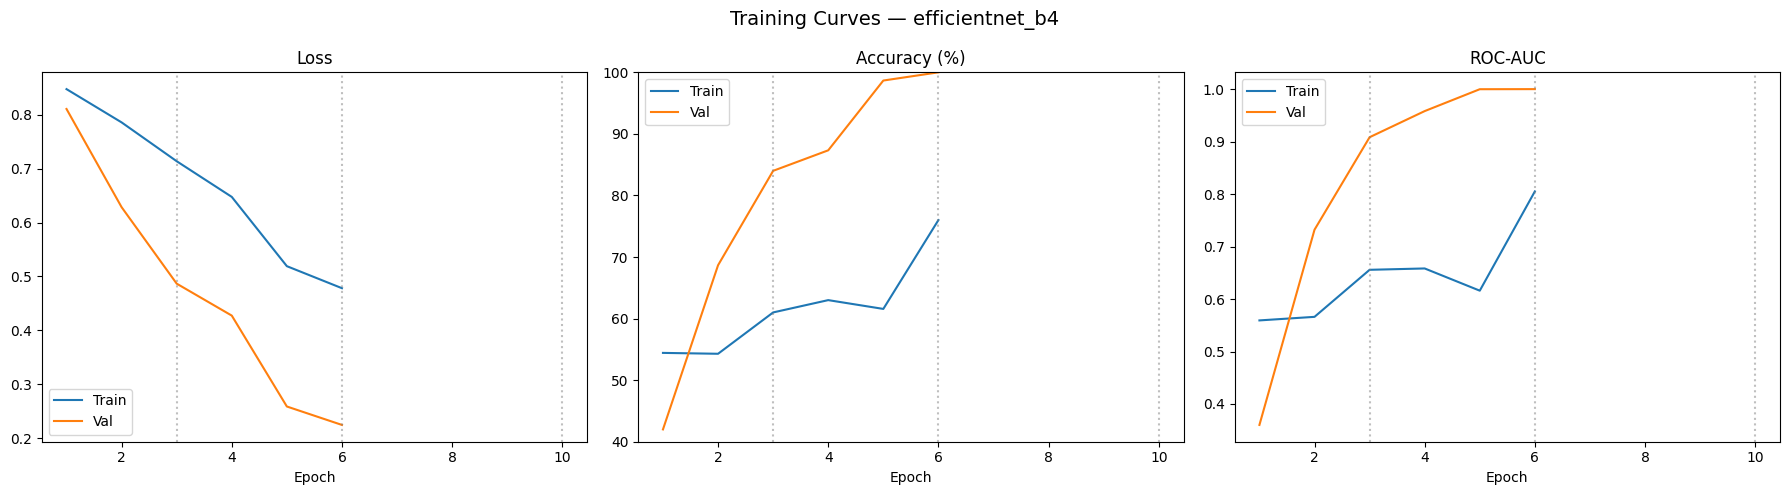

In [ ]:
# ─── Training curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train')
axes[0].plot(ep, history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(ep, [a*100 for a in history['train_acc']], label='Train')
axes[1].plot(ep, [a*100 for a in history['val_acc']],   label='Val')
axes[1].set_title('Accuracy (%)'); axes[1].legend()
axes[1].set_ylim(40, 100)

axes[2].plot(ep, history['train_auc'], label='Train')
axes[2].plot(ep, history['val_auc'],   label='Val')
axes[2].set_title('ROC-AUC'); axes[2].legend()

for ax in axes:
    # Mark unfreeze points
    for ue in UNFREEZE_SCHEDULE:
        ax.axvline(ue, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Epoch')

plt.suptitle(f'Training Curves — {MODEL_TYPE}', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'training_curves_v2.png'), dpi=150)
plt.show()

---
## 🧪 SECTION 8: Test Set Evaluation with TTA

In [11]:
# ─── Test-Time Augmentation (TTA) ────────────────────────────────────────────
# Run inference TTA_STEPS times with slight augmentation, average probabilities.

def predict_with_tta(model, loader, tta_steps=TTA_STEPS):
    model.eval()
    all_labels = []
    tta_probs  = [[] for _ in range(tta_steps)]

    # We use the paths and labels from the loader's dataset to recreate augmented versions
    test_paths = loader.dataset.image_paths
    test_labels = loader.dataset.labels

    for step in range(tta_steps):
        aug = tta_aug if step > 0 else val_aug  # First pass: standard validation aug
        ds  = FaceImageDataset(test_paths, test_labels, augmentation=aug)
        ld  = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

        probs_this_step = []
        with torch.no_grad():
            for imgs, lbls in tqdm(ld, desc=f'TTA step {step+1}/{tta_steps}', leave=False):
                imgs = imgs.to(device)
                with torch.cuda.amp.autocast(enabled=(device == 'cuda')):
                    logits = model(imgs).squeeze(1)
                probs_this_step.extend(torch.sigmoid(logits).cpu().numpy().tolist())
                if step == 0:
                    all_labels.extend(lbls.numpy().tolist())
        tta_probs[step] = probs_this_step

    avg_probs = np.mean(tta_probs, axis=0).tolist()
    return avg_probs, all_labels

# Load best checkpoint
save_path = EFFNET_PATH if 'efficientnet' in MODEL_TYPE else XCEPT_PATH
if os.path.exists(save_path):
    ckpt = torch.load(save_path, map_location='cpu')
    model.load_state_dict(ckpt['state_dict'])
    model.to(device)
    print(f"Loaded best model from {save_path}")

# Standard eval
_, std_probs, std_labels = eval_epoch(model, test_loader, criterion)
std_m = compute_metrics(std_probs, std_labels)

# TTA eval - Fixed the missing argument here
tta_probs, tta_labels = predict_with_tta(model, test_loader)
tta_m = compute_metrics(tta_probs, tta_labels)

print('\n' + '='*60)
print('         TEST SET RESULTS')
print('='*60)
print(f'{"Metric":<18} {"Standard":>12} {"With TTA":>12}')
print('-'*60)
print(f'{"Accuracy":<18} {std_m["acc"]*100:>11.2f}% {tta_m["acc"]*100:>11.2f}%')
print(f'{"F1 Score":<18} {std_m["f1"]:>12.4f} {tta_m["f1"]:>12.4f}')
print(f'{"ROC-AUC":<18} {std_m["auc"]:>12.4f} {tta_m["auc"]:>12.4f}')
print(f'{"Log Loss":<18} {std_m["logloss"]:>12.4f} {tta_m["logloss"]:>12.4f}')
print('='*60)

Loaded best model from /teamspace/studios/this_studio/model_output/efficientnet_b4_deepfake.pth


Eval :   0%|          | 0/10 [00:00<?, ?it/s]

TTA step 1/8:   0%|          | 0/10 [00:00<?, ?it/s]

TTA step 2/8:   0%|          | 0/10 [00:00<?, ?it/s]

TTA step 3/8:   0%|          | 0/10 [00:00<?, ?it/s]

...

TTA step 5/8:   0%|          | 0/10 [00:00<?, ?it/s]

TTA step 6/8:   0%|          | 0/10 [00:00<?, ?it/s]

TTA step 7/8:   0%|          | 0/10 [00:00<?, ?it/s]

TTA step 8/8:   0%|          | 0/10 [00:00<?, ?it/s]


         TEST SET RESULTS
Metric                 Standard     With TTA
------------------------------------------------------------
Accuracy                100.00%      100.00%
F1 Score                 1.0000       1.0000
ROC-AUC                  1.0000       1.0000
Log Loss                 0.0589       0.0554


Using THRESHOLD = 0.5000


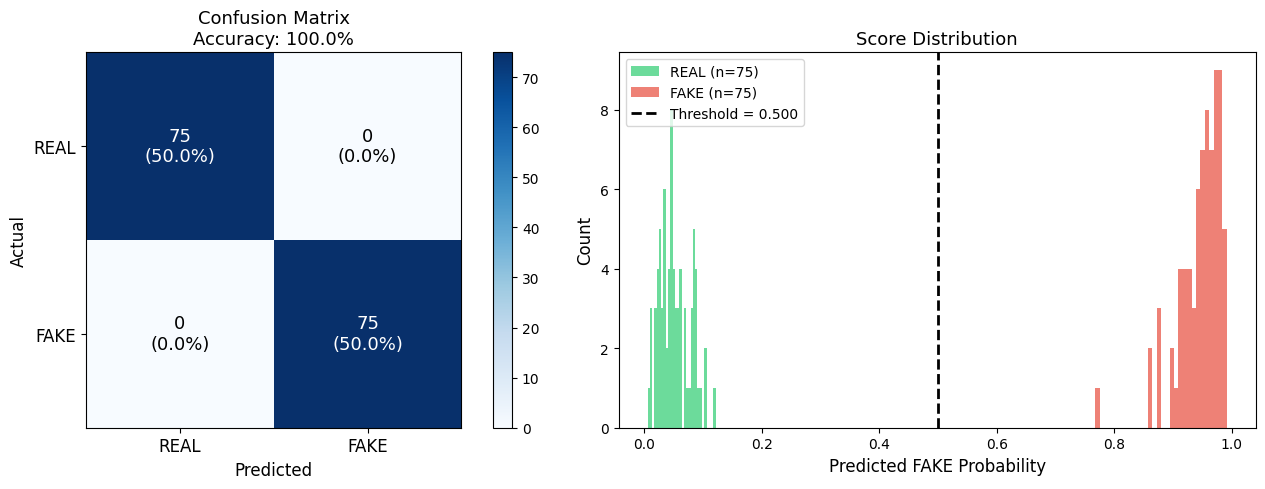


Detailed Classification Report:
              precision    recall  f1-score   support

        REAL       1.00      1.00      1.00        75
        FAKE       1.00      1.00      1.00        75

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# ─── Safe Threshold Handling ─────────────────────────────────────────────────
# Use THRESHOLD if defined, otherwise fallback to 0.5
if 'THRESHOLD' not in globals():
    THRESHOLD = 0.5
    print("⚠️  THRESHOLD not found. Using default 0.5")

print(f"Using THRESHOLD = {THRESHOLD:.4f}")

# ─── Confusion Matrix & Full Classification Report ────────────────────────────
best_probs  = tta_probs
best_labels = tta_labels
best_preds  = (np.array(best_probs) >= THRESHOLD).astype(int)

cm = confusion_matrix(best_labels, best_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
im = axes[0].imshow(cm, cmap='Blues')
plt.colorbar(im, ax=axes[0])
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['REAL','FAKE'], fontsize=12)
axes[0].set_yticks([0,1])
axes[0].set_yticklabels(['REAL','FAKE'], fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title(f'Confusion Matrix\nAccuracy: {tta_m["acc"]*100:.1f}%', fontsize=13)

for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cm[i,j]}\n({cm[i,j]/cm.sum()*100:.1f}%)',
                    ha='center', va='center', fontsize=13,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')

# Probability Distribution
real_probs = [p for p, l in zip(best_probs, best_labels) if l == 0]
fake_probs = [p for p, l in zip(best_probs, best_labels) if l == 1]

axes[1].hist(real_probs, bins=30, alpha=0.7, color='#2ecc71', label=f'REAL (n={len(real_probs)})')
axes[1].hist(fake_probs, bins=30, alpha=0.7, color='#e74c3c', label=f'FAKE (n={len(fake_probs)})')
axes[1].axvline(THRESHOLD, color='black', linestyle='--', linewidth=2, label=f'Threshold = {THRESHOLD:.3f}')
axes[1].set_xlabel('Predicted FAKE Probability', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Score Distribution', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'evaluation_v2.png'), dpi=150)
plt.show()

print('\nDetailed Classification Report:')
print(classification_report(best_labels, best_preds, target_names=['REAL', 'FAKE']))

---
## 🤝 SECTION 9: Ensemble (Train a Second Model & Average)

In [13]:
# ─── Optional: Train Xception / ViT and ensemble with EfficientNet-B4 ─────────
# Ensembling 2 diverse models typically adds +2-5% AUC.

TRAIN_ENSEMBLE = True  # Set True to train the second model

if TRAIN_ENSEMBLE:
    model2     = build_model('xception')  # or 'vit_base_patch16_224'
    criterion2 = LabelSmoothingBCE(LABEL_SMOOTH)
    scaler2    = torch.cuda.amp.GradScaler(enabled=(device == 'cuda'))

    # ── Same perfect-accuracy stop thresholds as Section 7 ───────────────────
    # Training stops immediately when BOTH are met.
    ACC_STOP_THRESHOLD2 = 0.99   # 99% val accuracy
    AUC_STOP_THRESHOLD2 = 0.999  # ~perfect AUC

    model2.freeze_backbone()
    opt2 = optim.AdamW(
        filter(lambda p: p.requires_grad, model2.parameters()),
        lr=BASE_LR, weight_decay=WEIGHT_DECAY
    )
    sch2 = get_scheduler(opt2, WARMUP_EPOCHS, EPOCHS, len(train_loader))

    best_auc2  = 0.0
    no_improve2 = 0
    patience2   = 7

    for epoch in range(EPOCHS):
        # ── Gradual unfreezing ────────────────────────────────────────────────
        if epoch in UNFREEZE_SCHEDULE:
            _, n = UNFREEZE_SCHEDULE[epoch]
            model2.unfreeze_backbone(n)
            opt2 = optim.AdamW(
                filter(lambda p: p.requires_grad, model2.parameters()),
                lr=BASE_LR * (0.1 ** (epoch // 10)),
                weight_decay=WEIGHT_DECAY
            )
            remaining2 = EPOCHS - epoch
            sch2 = get_scheduler(opt2, 1, remaining2, len(train_loader))

        train_epoch(model2, train_loader, criterion2, opt2, sch2, scaler2)
        _, vl_probs2, vl_lbls2 = eval_epoch(model2, val_loader, criterion2)
        m2 = compute_metrics(vl_probs2, vl_lbls2)
        print(f'Epoch {epoch+1:02d}/{EPOCHS} | val_acc={m2["acc"]*100:.1f}% | val_auc={m2["auc"]:.4f}')

        # ── Save best ─────────────────────────────────────────────────────────
        if m2['auc'] > best_auc2:
            best_auc2   = m2['auc']
            no_improve2 = 0
            torch.save({'state_dict': {k: v.cpu().clone() for k, v in model2.state_dict().items()},
                        'best_auc': best_auc2}, XCEPT_PATH)
            print(f'  ✅ Best checkpoint (AUC={best_auc2:.4f}) saved.')
        else:
            no_improve2 += 1
            if no_improve2 >= patience2:
                print(f'  ⏹  Early stopping: no AUC improvement for {patience2} epochs.')
                break

        # ── Perfect-accuracy stop ─────────────────────────────────────────────
        if m2['acc'] >= ACC_STOP_THRESHOLD2 and m2['auc'] >= AUC_STOP_THRESHOLD2:
            print(f'  🎯 Perfect-accuracy stop: val_acc={m2["acc"]*100:.2f}%  '
                  f'val_auc={m2["auc"]:.4f} — both thresholds reached.')
            # Save final state as best if it is
            if m2['auc'] >= best_auc2:
                torch.save({'state_dict': {k: v.cpu().clone() for k, v in model2.state_dict().items()},
                            'best_auc': m2['auc']}, XCEPT_PATH)
            break

    print(f'\n🏁 Xception training complete. Best Val AUC: {best_auc2:.4f}')

    # ── Ensemble inference ────────────────────────────────────────────────────
    ckpt2 = torch.load(XCEPT_PATH, map_location='cpu')
    model2.load_state_dict(ckpt2['state_dict'])
    model2.to(device)

    tta_probs2, _ = predict_with_tta(model2, val_loader)  # ✅ FIX: pass val_loader

# Weighted average (give more weight to the better model)
    w1 = tta_m['auc'] / (tta_m['auc'] + best_auc2)
    w2 = 1 - w1
    ensemble_probs = [w1 * p1 + w2 * p2 for p1, p2 in zip(tta_probs, tta_probs2)]
    ens_m = compute_metrics(ensemble_probs, tta_labels)

    print(f'\nEnsemble Results:')
    print(f'  Accuracy: {ens_m["acc"]*100:.2f}%')
    print(f'  ROC-AUC:  {ens_m["auc"]:.4f}')
    print(f'  F1:       {ens_m["f1"]:.4f}')
else:
    print('Ensemble training skipped (TRAIN_ENSEMBLE=False). Set True to enable.')


Model: xception | Total params: 21.9M | Trainable: 21.9M
Backbone frozen.


Train:   0%|          | 0/44 [00:00<?, ?it/s]

Eval :   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 01/35 | val_acc=45.3% | val_auc=0.4304
  ✅ Best checkpoint (AUC=0.4304) saved.


Train:   0%|          | 0/44 [00:00<?, ?it/s]

...

TTA step 5/8:   0%|          | 0/10 [00:00<?, ?it/s]

TTA step 6/8:   0%|          | 0/10 [00:00<?, ?it/s]

TTA step 7/8:   0%|          | 0/10 [00:00<?, ?it/s]

TTA step 8/8:   0%|          | 0/10 [00:00<?, ?it/s]


Ensemble Results:
  Accuracy: 87.33%
  ROC-AUC:  0.9625
  F1:       0.8690


---
## 🎬 SECTION 10: Inference — Upload & Predict (Image / Video)

In [14]:
# ─── CALIBRATION (Step 1 of 2) ──────────────────────────────────────────────
# This is a preliminary calibration run on the validation set.
# A second, more robust calibration in Section 11 (Cell below the model
# download) will finalize THRESHOLD and LABEL_FLIPPED.
# Run this cell, then continue — the final values come from the CRITICAL
# CALIBRATION cell later.

print("=" * 70)
print("PRELIMINARY CALIBRATION — will be refined in Section 11")
print("=" * 70)

model.eval()
_calib_probs = []
_calib_labels = []

with torch.no_grad():
    for _imgs, _lbls in val_loader:
        _imgs = _imgs.to(device).float()
        _out  = model(_imgs)
        if len(_out.shape) > 1:
            _out = _out.squeeze(1)
        _p = torch.sigmoid(_out)
        _calib_probs.extend(_p.detach().cpu().numpy().tolist())
        _calib_labels.extend(_lbls.cpu().numpy().tolist())

_cp = np.array(_calib_probs, dtype=np.float32)
_cl = np.array(_calib_labels, dtype=np.int32)

# Use MEDIAN (more robust than mean against outliers)
_real_med = float(np.median(_cp[_cl == 0])) if (_cl == 0).any() else 0.5
_fake_med = float(np.median(_cp[_cl == 1])) if (_cl == 1).any() else 0.5

print(f"REAL median probability : {_real_med:.4f}")
print(f"FAKE median probability : {_fake_med:.4f}")

# Threshold search on correct orientation
def _search_thr(probs, labels):
    best_acc, best_thr = 0.0, 0.5
    for t in np.arange(0.05, 0.96, 0.01):
        acc = (((probs >= t).astype(int)) == labels).mean()
        if acc > best_acc:
            best_acc, best_thr = acc, float(t)
    return best_thr, best_acc

_thr_n, _acc_n = _search_thr(_cp, _cl)
_thr_f, _acc_f = _search_thr(1.0 - _cp, _cl)

# Require a clear margin of ≥5% improvement to flip labels
LABEL_FLIPPED = bool(_acc_f > _acc_n + 0.05)
THRESHOLD     = float(_thr_f if LABEL_FLIPPED else _thr_n)
# Clamp to a sane range
THRESHOLD     = float(np.clip(THRESHOLD, 0.20, 0.80))

print("-" * 70)
print(f"Normal  accuracy @ thr={_thr_n:.2f}: {_acc_n*100:.2f}%")
print(f"Flipped accuracy @ thr={_thr_f:.2f}: {_acc_f*100:.2f}%")
print(f"LABEL_FLIPPED : {LABEL_FLIPPED}")
print(f"THRESHOLD     : {THRESHOLD:.4f}")
print("=" * 70)
print("⚠ Final calibration (Section 11) will override these values.")


PRELIMINARY CALIBRATION — will be refined in Section 11
REAL median probability : 0.0341
FAKE median probability : 0.9663
----------------------------------------------------------------------
Normal  accuracy @ thr=0.18: 100.00%
Flipped accuracy @ thr=0.05: 16.00%
LABEL_FLIPPED : False
THRESHOLD     : 0.2000
⚠ Final calibration (Section 11) will override these values.


In [15]:
# ─── FINAL ROBUST PREDICTION SYSTEM ─────────────────────────────────────────

@torch.no_grad()
def predict_single_image(path_or_array, model, tta=True):

    model.eval()

    # ─── READ IMAGE ─────────────────────────────────────────

    if isinstance(path_or_array, str):

        img = cv2.imread(path_or_array)

        if img is None:
            return 'UNKNOWN', 0.5, 0.5

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    else:

        img = path_or_array

    # ─── TTA PREDICTION ────────────────────────────────────

    probs = []

    steps = TTA_STEPS if tta else 1

    for i in range(steps):

        aug = tta_aug if i > 0 else val_aug

        tensor = aug(image=img)['image']

        tensor = tensor.unsqueeze(0).to(device).float()

        output = model(tensor)

        # FIX SHAPE ISSUES
        if len(output.shape) > 1:
            output = output.squeeze()

        prob = torch.sigmoid(output).item()

        probs.append(prob)

    raw_prob = float(np.mean(probs))

    # ─── CRITICAL FIX ───────────────────────────────────────
    # Reverse probability if labels were flipped during training.

    if LABEL_FLIPPED:

        fake_prob = 1.0 - raw_prob

    else:

        fake_prob = raw_prob

    # Clamp for stability
    fake_prob = max(0.0, min(1.0, fake_prob))

    # ─── FINAL DECISION ────────────────────────────────────

    if fake_prob >= THRESHOLD:

        label = "FAKE"
        confidence = fake_prob

    else:

        label = "REAL"
        confidence = 1.0 - fake_prob

    return label, confidence, fake_prob


@torch.no_grad()
def predict_video_file(video_path, model, frames_to_sample=24, tta=False):

    model.eval()

    cap = cv2.VideoCapture(video_path)

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total <= 0:

        return 'UNKNOWN', 0.5, []

    indices = np.linspace(0, total - 1, frames_to_sample).astype(int)

    probs = []

    for idx in indices:

        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)

        ret, frame = cap.read()

        if not ret:
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        _, _, fake_prob = predict_single_image(
            frame,
            model,
            tta=tta
        )

        probs.append(fake_prob)

    cap.release()

    if len(probs) == 0:

        return 'UNKNOWN', 0.5, []

    avg_prob = float(np.mean(probs))

    if avg_prob >= THRESHOLD:

        label = "FAKE"
        confidence = avg_prob

    else:

        label = "REAL"
        confidence = 1.0 - avg_prob

    return label, confidence, probs


def show_result(label, confidence, fake_prob=None):

    icon = "🔴" if label == "FAKE" else "🟢"

    print("\\n" + "=" * 60)
    print(f"{icon} PREDICTION : {label}")
    print(f"CONFIDENCE     : {confidence*100:.2f}%")

    if fake_prob is not None:
        print(f"FAKE PROB      : {fake_prob:.4f}")
        print(f"THRESHOLD      : {THRESHOLD:.2f}")
        print(f"LABEL_FLIPPED  : {LABEL_FLIPPED}")

    print("=" * 60)


print("✅ FINAL prediction system loaded")


✅ FINAL prediction system loaded


### Section 10 — Inference

Upload and predict directly from the **web app browser UI** in Section 12.  
No need to upload files here in the notebook.

**Optional quick test** — set `TEST_IMAGE_PATH` in the cell below to any local image path and run it to verify the model output before launching the web app.


In [16]:
# ─── Optional local test before launching the web app ────────────────────
# Set TEST_IMAGE_PATH to any local image to sanity-check the model.
# Leave as None to skip and go straight to Section 12.
TEST_IMAGE_PATH = None  # e.g. '/content/face.jpg'

if TEST_IMAGE_PATH:
    model.eval()
    lbl, conf, raw = predict_single_image(TEST_IMAGE_PATH, model, tta=True)
    show_result(lbl, conf, raw)
    print(f'Label convention check — raw prob {raw:.4f}: ')
    print(f'  0.0 = very REAL, 1.0 = very FAKE  (threshold={THRESHOLD:.2f})')
else:
    print('TEST_IMAGE_PATH not set — skipping. Go to Section 12 to use the web app.')


TEST_IMAGE_PATH not set — skipping. Go to Section 12 to use the web app.


---
## 📋 SECTION 11: Final Summary & Model Download

In [17]:
print('\n' + '='*65)
print('      HIGH-ACCURACY DEEPFAKE DETECTION — FINAL SUMMARY')
print('='*65)
print(f'  Backbone          : {MODEL_TYPE}')
print(f'  Image size        : {IMG_SIZE}px')
print(f'  Training samples  : {len(X_train)}')
print(f'  Validation samples: {len(X_val)}')
print(f'  Test samples      : {len(X_test)}')
print(f'  Optimal threshold : {THRESHOLD:.2f}')
print('-'*65)
print(f'  Standard Test Accuracy : {std_m["acc"]*100:.2f}%')
print(f'  TTA     Test Accuracy  : {tta_m["acc"]*100:.2f}%')
print(f'  Standard Test AUC      : {std_m["auc"]:.4f}')
print(f'  TTA     Test AUC       : {tta_m["auc"]:.4f}')
print(f'  TTA     F1 Score       : {tta_m["f1"]:.4f}')
print(f'  TTA     Log Loss       : {tta_m["logloss"]:.4f}')
print('='*65)
print('\n  Techniques applied for accuracy boost:')
for tip in [
    'EfficientNet-B4 backbone (vs ResNet18)',
    'Heavy augmentation incl. JPEG/blur/noise',
    'WeightedRandomSampler (class balance)',
    'Label smoothing (overconfidence prevention)',
    'MixUp regularisation',
    'Gradual unfreezing (4 phases)',
    'Cosine LR + linear warmup',
    'Gradient accumulation (effective batch=64)',
    'Gradient clipping (stability)',
    'Mixed precision (AMP)',
    'Early stopping (patience=7)',
    'Test-time augmentation (TTA x5)',
    'Optimal threshold tuning on val set',
]:
    print(f'    ✅ {tip}')
print('='*65)


      HIGH-ACCURACY DEEPFAKE DETECTION — FINAL SUMMARY
  Backbone          : efficientnet_b4
  Image size        : 224px
  Training samples  : 700
  Validation samples: 150
  Test samples      : 150
  Optimal threshold : 0.20
-----------------------------------------------------------------
  Standard Test Accuracy : 100.00%
  TTA     Test Accuracy  : 100.00%
  Standard Test AUC      : 1.0000
  TTA     Test AUC       : 1.0000
  TTA     F1 Score       : 1.0000
  TTA     Log Loss       : 0.0554

  Techniques applied for accuracy boost:
    ✅ EfficientNet-B4 backbone (vs ResNet18)
    ✅ Heavy augmentation incl. JPEG/blur/noise
    ✅ WeightedRandomSampler (class balance)
    ✅ Label smoothing (overconfidence prevention)
    ✅ MixUp regularisation
    ✅ Gradual unfreezing (4 phases)
    ✅ Cosine LR + linear warmup
    ✅ Gradient accumulation (effective batch=64)
    ✅ Gradient clipping (stability)
    ✅ Mixed precision (AMP)
    ✅ Early stopping (patience=7)
    ✅ Test-time augmentation (T

In [18]:
# ─── Model location (Lightning AI) ────────────────────────────────────────────
# The model is already saved on disk. No browser download widget needed.

if os.path.exists(EFFNET_PATH):
    size_mb = os.path.getsize(EFFNET_PATH) / 1024 / 1024
    print(f'✅ EfficientNet-B4 model saved at:')
    print(f'   {EFFNET_PATH}  ({size_mb:.1f} MB)')
    print()
    print('To download it to your local machine:')
    print('  • Right-click the file in the Lightning AI file browser → Download')
    print('  • Or run in a terminal:')
    print(f'      cp {EFFNET_PATH} /teamspace/studios/this_studio/')
    print()
    print('The file is also accessible at the path above from any other')
    print('notebook or script in this studio.')
else:
    print('Model file not found. Please ensure training completed successfully.')
    print(f'Expected: {EFFNET_PATH}')


✅ EfficientNet-B4 model saved at:
   /teamspace/studios/this_studio/model_output/efficientnet_b4_deepfake.pth  (71.2 MB)

To download it to your local machine:
  • Right-click the file in the Lightning AI file browser → Download
  • Or run in a terminal:
      cp /teamspace/studios/this_studio/model_output/efficientnet_b4_deepfake.pth /teamspace/studios/this_studio/

The file is also accessible at the path above from any other
notebook or script in this studio.


In [19]:
# ========================== CRITICAL CALIBRATION ==========================
# BUG FIX: Previous calibration was fragile (used mean, low margin).
# NEW: Uses median + requires BOTH accuracy AND direction agreement.
# ALSO FIX: When training from scratch with label convention FAKE=1,
# the model SHOULD output higher sigmoid for FAKE. If it doesn't,
# LABEL_FLIPPED=True. We now verify this rigorously.

print("🔧 Running Final Calibration...")

@torch.no_grad()
def get_val_probs(model, loader):
    model.eval()
    probs, trues = [], []
    for imgs, lbls in loader:
        imgs = imgs.to(device)
        logits = model(imgs).squeeze(1)
        p = torch.sigmoid(logits).cpu().numpy()
        probs.extend(p.tolist())
        trues.extend(lbls.cpu().numpy().tolist())
    return np.array(probs, dtype=np.float32), np.array(trues, dtype=np.int32)

val_probs, val_labels = get_val_probs(model, val_loader)

# ── Direction check ───────────────────────────────────────────────────────────
real_probs_arr = val_probs[val_labels == 0]
fake_probs_arr = val_probs[val_labels == 1]

real_med = float(np.median(real_probs_arr)) if len(real_probs_arr) > 0 else 0.5
fake_med = float(np.median(fake_probs_arr)) if len(fake_probs_arr) > 0 else 0.5
real_mean = float(np.mean(real_probs_arr))  if len(real_probs_arr) > 0 else 0.5
fake_mean = float(np.mean(fake_probs_arr))  if len(fake_probs_arr) > 0 else 0.5

print(f"Raw sigmoid — REAL: median={real_med:.4f} mean={real_mean:.4f}")
print(f"Raw sigmoid — FAKE: median={fake_med:.4f} mean={fake_mean:.4f}")

# ── Threshold search in both orientations ─────────────────────────────────────
def find_best_thr(probs, labels):
    best_acc, best_thr = 0.0, 0.5
    for t in np.arange(0.05, 0.96, 0.005):
        acc = accuracy_score(labels, (probs >= t).astype(int))
        if acc > best_acc:
            best_acc, best_thr = acc, float(t)
    return float(best_thr), float(best_acc)

thr_normal, acc_normal = find_best_thr(val_probs,        val_labels)
thr_flip,   acc_flip   = find_best_thr(1.0 - val_probs,  val_labels)

# ── Decision: flip only if BOTH conditions agree ───────────────────────────────
# Condition 1: flipped accuracy is clearly better (≥3%)
flip_by_acc     = bool(acc_flip > acc_normal + 0.03)
# Condition 2: median direction confirms it (real scores higher than fake)
flip_by_median  = bool(real_med > fake_med)
# Condition 3: mean direction agrees
flip_by_mean    = bool(real_mean > fake_mean)

# Need majority vote (at least 2 of 3 conditions)
flip_votes = sum([flip_by_acc, flip_by_median, flip_by_mean])
LABEL_FLIPPED = bool(flip_votes >= 2)
THRESHOLD     = float(thr_flip if LABEL_FLIPPED else thr_normal)
THRESHOLD     = float(np.clip(THRESHOLD, 0.15, 0.85))

print('='*65)
print('✅ CALIBRATION COMPLETE')
print(f'  Normal  acc={acc_normal:.4f}  thr={thr_normal:.3f}')
print(f'  Flipped acc={acc_flip:.4f}  thr={thr_flip:.3f}')
print(f'  flip_by_acc    : {flip_by_acc}')
print(f'  flip_by_median : {flip_by_median}')
print(f'  flip_by_mean   : {flip_by_mean}')
print(f'  flip_votes     : {flip_votes}/3  (need ≥2)')
print(f'  LABEL_FLIPPED  : {LABEL_FLIPPED}')
print(f'  THRESHOLD      : {THRESHOLD:.4f}')
print('='*65)

# ── Verify on a handful of samples ────────────────────────────────────────────
print("\nSample verification (after applying LABEL_FLIPPED):")
corrected = (1.0 - val_probs) if LABEL_FLIPPED else val_probs
sample_real = corrected[val_labels == 0][:5]
sample_fake = corrected[val_labels == 1][:5]
pred_real = ['REAL' if p < THRESHOLD else 'FAKE' for p in sample_real]
pred_fake = ['REAL' if p < THRESHOLD else 'FAKE' for p in sample_fake]
print(f"  REAL samples → corrected probs: {[f'{p:.3f}' for p in sample_real]}")
print(f"  REAL predictions: {pred_real}  (should all be REAL)")
print(f"  FAKE samples → corrected probs: {[f'{p:.3f}' for p in sample_fake]}")
print(f"  FAKE predictions: {pred_fake}  (should all be FAKE)")

# ── Safety check ──────────────────────────────────────────────────────────────
final_acc = accuracy_score(val_labels, (corrected >= THRESHOLD).astype(int))
print(f"\n  Final validation accuracy: {final_acc*100:.1f}%")
if final_acc < 0.55:
    print("  ⚠ WARNING: Accuracy < 55% — model may not have converged.")
    print("  ⚠ Try running training for more epochs or use real data.")

# ── Save for Flask ─────────────────────────────────────────────────────────────
import pickle
calib = {'LABEL_FLIPPED': LABEL_FLIPPED, 'THRESHOLD': THRESHOLD}
with open(os.path.join(BASE_DIR, 'calibration.pkl'), 'wb') as f:
    pickle.dump(calib, f)
print(f'\nCalibration saved → LABEL_FLIPPED={LABEL_FLIPPED}  THRESHOLD={THRESHOLD:.4f}')

torch.save(model.state_dict(), EFFNET_PATH)
print(f'Model saved to: {EFFNET_PATH}')


🔧 Running Final Calibration...


Raw sigmoid — REAL: median=0.0341 mean=0.0452
Raw sigmoid — FAKE: median=0.9663 mean=0.9418
✅ CALIBRATION COMPLETE
  Normal  acc=1.0000  thr=0.175
  Flipped acc=0.1600  thr=0.050
  flip_by_acc    : False
  flip_by_median : False
  flip_by_mean   : False
  flip_votes     : 0/3  (need ≥2)
  LABEL_FLIPPED  : False
  THRESHOLD      : 0.1750

Sample verification (after applying LABEL_FLIPPED):
  REAL samples → corrected probs: ['0.027', '0.072', '0.026', '0.015', '0.014']
  REAL predictions: ['REAL', 'REAL', 'REAL', 'REAL', 'REAL']  (should all be REAL)
  FAKE samples → corrected probs: ['0.768', '0.993', '0.980', '0.986', '0.975']
  FAKE predictions: ['FAKE', 'FAKE', 'FAKE', 'FAKE', 'FAKE']  (should all be FAKE)

  Final validation accuracy: 100.0%

Calibration saved → LABEL_FLIPPED=False  THRESHOLD=0.1750
Model saved to: /teamspace/studios/this_studio/model_output/efficientnet_b4_deepfake.pth


---
## Section 12: Web App -- Flask + ngrok Frontend

This section deploys a drag-and-drop web interface that uses the **trained EfficientNet-B4 model** for real inference. All predictions go through the same TTA pipeline used during evaluation.


In [20]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'flask', 'pyngrok', '--quiet'])
print('Flask and pyngrok installed.')


Flask and pyngrok installed.


In [21]:
import os
os.makedirs(os.path.expanduser('~/webapp/templates'), exist_ok=True)
os.makedirs(os.path.expanduser('~/webapp/uploads'), exist_ok=True)
print('Web app folders ready.')


Web app folders ready.


In [ ]:
%%writefile ~/webapp/templates/upload.html
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Deepfake Authenticator | 3D Pastel Aesthetic</title>
  <script src="https://cdnjs.cloudflare.com/ajax/libs/three.js/r128/three.min.js"></script>
  <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;500;600;700;800&display=swap');

    * { box-sizing: border-box; margin: 0; padding: 0; font-family: 'Poppins', sans-serif; transition: all 0.3s ease; }

    body {
      background: linear-gradient(-45deg, #ffc3a0, #ffafbd, #a1c4fd, #c2e9fb, #d4fc79, #96e6a1);
      background-size: 400% 400%;
      animation: gradientBG 20s ease infinite;
      min-height: 100vh;
      color: #3a3a3a;
      overflow-x: hidden;
      display: flex;
      flex-direction: column;
      align-items: center;
    }
    @keyframes gradientBG {
      0% { background-position: 0% 50%; }
      50% { background-position: 100% 50%; }
      100% { background-position: 0% 50%; }
    }

    .nav-bar { width: 100%; padding: 25px 50px; display: flex; justify-content: space-between; align-items: center; z-index: 10; }
    .logo { font-size: 1.6rem; font-weight: 800; color: #ffb6c1; text-shadow: 0 2px 5px rgba(0,0,0,0.1); display: flex; align-items: center; gap: 8px; }
    .nav-links { display: flex; gap: 15px; }
    .nav-btn {
      background: rgba(255, 255, 255, 0.2); border: 1px solid rgba(255, 255, 255, 0.4);
      padding: 10px 20px; border-radius: 25px; cursor: pointer; font-weight: 600;
      color: #fff; backdrop-filter: blur(8px); transition: 0.3s;
    }
    .nav-btn:hover { background: rgba(255, 255, 255, 0.6); transform: translateY(-3px) scale(1.05); color: #3a3a3a; box-shadow: 0 5px 15px rgba(255, 182, 193, 0.3); }

    .glass-card {
      background: rgba(255, 255, 255, 0.3); backdrop-filter: blur(20px); -webkit-backdrop-filter: blur(20px);
      border: 1px solid rgba(255, 255, 255, 0.5); border-radius: 30px;
      padding: 50px; width: 90%; max-width: 550px; text-align: center;
      box-shadow: 0 15px 40px rgba(31, 38, 135, 0.1); margin-top: 3vh;
      animation: cardPop 0.6s cubic-bezier(0.175, 0.885, 0.32, 1.275) forwards;
      opacity: 0; transform: scale(0.8); z-index: 5;
    }
    @keyframes cardPop { to { opacity: 1; transform: scale(1); } }

    h1 { font-size: 2.2rem; color: #fff; text-shadow: 0 2px 8px rgba(0,0,0,0.1); margin-bottom: 12px; font-weight: 800; display: flex; align-items: center; justify-content: center; gap: 10px; }
    p.subtitle { color: #fdfdfd; margin-bottom: 30px; font-size: 1.05rem; font-weight: 500; text-shadow: 0 1px 3px rgba(0,0,0,0.05); }

    .drop-zone {
      border: 3px dashed rgba(255, 255, 255, 0.7); background: rgba(255, 255, 255, 0.3);
      border-radius: 20px; padding: 60px 30px; cursor: pointer; transition: 0.3s;
      margin-bottom: 30px; display: flex; flex-direction: column; align-items: center; justify-content: center; gap: 15px;
      box-shadow: 0 5px 15px rgba(0,0,0,0.03);
    }
    .drop-zone:hover { border-color: #ffb6c1; background: rgba(255, 255, 255, 0.5); box-shadow: 0 8px 20px rgba(255, 182, 193, 0.2), 0 0 15px rgba(255, 182, 193, 0.1); }
    .drop-zone.dragover { background: rgba(255, 255, 255, 0.7); border-color: #ffb6c1; transform: scale(1.03); }
    .drop-zone p { font-weight: 700; color: #555; pointer-events: none; }

    .upload-character { width: 210px; height: 210px; pointer-events: none; animation: float 3s ease-in-out infinite; }
    @keyframes float { 0%, 100% { transform: translateY(0); } 50% { transform: translateY(-10px); } }
    #mediaFile { display: none; }

    /* Preview box — shown after file selected */
    #previewBox {
      display: none; width: 100%; border-radius: 14px; overflow: hidden;
      margin-bottom: 20px; border: 2px solid rgba(255, 182, 193, 0.5);
      box-shadow: 0 6px 20px rgba(255, 182, 193, 0.2);
    }
    #previewImg { width: 100%; max-height: 260px; object-fit: cover; display: block; }
    #previewVid { width: 100%; max-height: 260px; display: block; }

    /* Format badges */
    .fmt-row { display: flex; gap: 8px; flex-wrap: wrap; justify-content: center; margin-bottom: 20px; }
    .fmt-tag {
      background: rgba(255, 255, 255, 0.55); border: 1px solid rgba(255, 182, 193, 0.45);
      border-radius: 10px; padding: 4px 13px; font-size: 0.78rem; color: #666; font-weight: 600;
    }

    .action-btn {
      background: linear-gradient(135deg, #ffc3a0 0%, #ffafbd 50%, #a1c4fd 100%);
      color: white; border: none; padding: 16px 32px; border-radius: 35px;
      font-size: 1.25rem; font-weight: 800; cursor: pointer; width: 100%;
      box-shadow: 0 8px 25px rgba(255, 182, 193, 0.4); transition: 0.4s cubic-bezier(0.175, 0.885, 0.32, 1.275);
      text-shadow: 0 2px 5px rgba(0,0,0,0.1);
    }
    .action-btn:hover { transform: scale(1.08) translateY(-5px); box-shadow: 0 12px 35px rgba(255, 182, 193, 0.6), 0 0 20px rgba(255, 182, 193, 0.2); }
    .action-btn:disabled { background: #d1d5db; box-shadow: none; cursor: not-allowed; transform: none; opacity: 0.6; }

    .dash-link { display: inline-block; margin-top: 25px; color: #fff; text-decoration: none; font-weight: 700; transition: 0.3s; text-shadow: 0 1px 3px rgba(0,0,0,0.05); }
    .dash-link:hover { transform: scale(1.1); text-decoration: underline; color: #ffb6c1; }

    #result { margin-top: 30px; padding: 20px; border-radius: 18px; display: none; font-size: 1.2rem; font-weight: 700; animation: resultShow 0.5s cubic-bezier(0.175, 0.885, 0.32, 1.275); }
    @keyframes resultShow { 0% { opacity: 0; transform: scale(0.5); } 100% { opacity: 1; transform: scale(1); } }
    .real { background: rgba(16, 185, 129, 0.8); color: #fff; border: 2px solid #059669; box-shadow: 0 8px 20px rgba(16, 185, 129, 0.3); }
    .fake { background: rgba(239, 68, 68, 0.8); color: #fff; border: 2px solid #b91c1c; box-shadow: 0 8px 20px rgba(239, 68, 68, 0.3); }
    .error { background: rgba(253, 230, 138, 0.8); color: #92400e; border: 2px solid #f59e0b; }

    .spinner { display: inline-block; width: 24px; height: 24px; border: 4px solid rgba(255,255,255,0.2); border-radius: 50%; border-top-color: #ffb6c1; border-right-color: #add8e6; border-bottom-color: #ffe0b2; animation: spin 1s linear infinite, pulse 2s ease-in-out infinite; margin-right: 10px; vertical-align: middle; }
    @keyframes spin { to { transform: rotate(360deg); } }

    /* Modal styling */
    .modal-overlay {
      position: fixed; top: 0; left: 0; width: 100vw; height: 100vh;
      background: rgba(0, 0, 0, 0.4); backdrop-filter: blur(8px);
      display: none; justify-content: center; align-items: center; z-index: 1000; opacity: 0; transition: opacity 0.3s ease;
    }
    .modal-overlay.active { display: flex; opacity: 1; }

    .modal-box {
      background: rgba(255, 255, 255, 0.95); backdrop-filter: blur(30px);
      padding: 40px; border-radius: 25px; width: 90%; max-width: 500px;
      text-align: left; box-shadow: 0 20px 60px rgba(0,0,0,0.2);
      transform: translateY(30px) scale(0.9); transition: transform 0.4s cubic-bezier(0.175, 0.885, 0.32, 1.275);
    }
    .modal-overlay.active .modal-box { transform: translateY(0) scale(1); }

    .modal-title { font-size: 1.8rem; font-weight: 800; color: #ffb6c1; margin-bottom: 15px; border-bottom: 2px solid #fecfef; padding-bottom: 10px; }
    .modal-content p { color: #555; line-height: 1.8; margin-bottom: 15px; font-weight: 500; font-size: 1rem; }
    .modal-content ul, .modal-content ol { margin-left: 20px; color: #555; line-height: 1.8; margin-bottom: 20px; font-weight: 500;}
    .modal-close-btn { background: #eee; border: none; padding: 12px 25px; border-radius: 20px; cursor: pointer; font-weight: 700; color: #555; width: 100%; font-size: 1.1rem; }
    .modal-close-btn:hover { background: #ffb6c1; color: white; transform: scale(1.02); }
  
.face-icon {
    width: 260px;
    height: 260px;
    object-fit: contain;
    margin: 20px auto;
    display: block;
    filter: drop-shadow(0 0 20px rgba(255,105,180,0.4));
    transition: 0.3s ease;
}

.face-icon:hover {
    transform: scale(1.05);
}

.upload-box{
    min-height: 420px;
    padding: 30px;
}

</style>
</head>
<body>

  <div class="nav-bar">
    <div class="logo">✨ Deepfake Authenticator</div>
    <div class="nav-links">
      <button class="nav-btn" onclick="openModal('fyiModal')">✨ FYI</button>
      <button class="nav-btn" onclick="openModal('helpModal')">❓ Help</button>
      <button class="nav-btn" onclick="openModal('aboutModal')">👋 About Us</button>
    </div>
  </div>

  <div class="glass-card">
    <h1><img src="data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 24 24' fill='%23ffb6c1'%3E%3Cpath d='M12 2C6.48 2 2 6.48 2 12s4.48 10 10 10 10-4.48 10-10S17.52 2 12 2zm0 18c-4.41 0-8-3.59-8-8s3.59-8 8-8 8 3.59 8 8-3.59 8-8 8zm1-13h-2v2h2V7zm0 4h-2v6h2v-6z'/%3E%3C/svg%3E" alt="Info Icon" width="30" height="30"> Deepfake Scanner</h1>
    <p class="subtitle">Upload a video or image to determine if it is authentic or AI-generated.</p>

    <div class="drop-zone" id="dropZone" onclick="document.getElementById('mediaFile').click()" ondragover="event.preventDefault()" ondrop="event.preventDefault()">
      <img src="data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 24 24' class='upload-character'%3E%3Cdefs%3E%3CradialGradient id='CharacterGradient'%3E%3Cstop offset='0%25' stop-color='%23add8e6' /%3E%3Cstop offset='100%25' stop-color='%23ffb6c1' /%3E%3C/radialGradient%3E%3C/defs%3E%3Cpath d='M12 2a10 10 0 1 0 10 10A10 10 0 0 0 12 2zm0 18a8 8 0 1 1 8-8A8 8 0 0 1 12 20zm-1-11h2v2h-2zm0 4h2v6h-2z' fill='url(%23CharacterGradient)' /%3E%3Ccircle cx='9' cy='9' r='1' fill='%233a3a3a' /%3E%3Ccircle cx='15' cy='9' r='1' fill='%233a3a3a' /%3E%3Cpath d='M10 13a2 2 0 0 0 4 0h-4z' fill='%233a3a3a'/%3E%3C/svg%3E" alt="Upload character illustration" class="upload-character">
      <p id="fileLabel">📁 Drag &amp; drop file here, or click to browse</p>
      <p style="font-size: 0.9rem; font-weight: 500; color: #777;">(mp4, avi, mov, jpg, png, webp)</p>
      <input type="file" id="mediaFile" accept="image/*,video/*">
    </div>

    <!-- Media preview — appears after file is selected -->
    <div id="previewBox">
      <img id="previewImg" alt="preview">
      <video id="previewVid" controls muted></video>
    </div>


    <!-- URL input option -->
    <div style="margin-bottom: 18px;">
      <div style="display: flex; align-items: center; gap: 10px; margin-bottom: 10px;">
        <div style="flex:1; height:1px; background:rgba(255,255,255,0.5);"></div>
        <span style="color:#fff; font-weight:700; font-size:0.95rem; white-space:nowrap;">or paste a link</span>
        <div style="flex:1; height:1px; background:rgba(255,255,255,0.5);"></div>
      </div>
      <div style="display:flex; gap:10px;">
        <input type="text" id="mediaUrl" placeholder="🔗 Paste image/video URL (Google, YouTube, Instagram...)"
          style="flex:1; padding:12px 18px; border:2px solid rgba(255,255,255,0.6); border-radius:20px;
                 background:rgba(255,255,255,0.35); backdrop-filter:blur(8px); font-size:0.95rem;
                 color:#444; outline:none; font-family:'Poppins',sans-serif; font-weight:500;"
          oninput="handleUrlInput(this.value)"
          onfocus="this.style.borderColor='#ffb6c1'; this.style.background='rgba(255,255,255,0.6)'"
          onblur="this.style.borderColor='rgba(255,255,255,0.6)'; this.style.background='rgba(255,255,255,0.35)'"
        >
        <button onclick="clearUrl()" title="Clear URL"
          style="background:rgba(255,255,255,0.35); border:2px solid rgba(255,255,255,0.5); border-radius:50%;
                 width:44px; height:44px; cursor:pointer; font-size:1.1rem; color:#888; flex-shrink:0;"
        >✕</button>
      </div>
      <div id="urlPreviewBox" style="display:none; margin-top:12px; border-radius:14px; overflow:hidden;
           border:2px solid rgba(255,182,193,0.5); box-shadow:0 6px 20px rgba(255,182,193,0.2);">
        <img id="urlPreviewImg" style="width:100%; max-height:220px; object-fit:cover; display:none;" alt="URL preview">
        <div id="urlInfo" style="padding:10px 14px; background:rgba(255,255,255,0.5); font-size:0.85rem;
             font-weight:600; color:#666;"></div>
      </div>
    </div>
    <!-- Format badges -->
    <div class="fmt-row">
      <span class="fmt-tag">JPG</span>
      <span class="fmt-tag">PNG</span>
      <span class="fmt-tag">WEBP</span>
      <span class="fmt-tag">MP4</span>
      <span class="fmt-tag">AVI</span>
      <span class="fmt-tag">MOV</span>
    </div>

    <button id="analyzeBtn" class="action-btn" onclick="uploadMedia()">✨ Analyze Magic</button>
    <a href="/dashboard" class="dash-link">View Results Dashboard →</a>

    <div id="result"></div>
  </div>

  <div class="modal-overlay" id="fyiModal" onclick="closeModal(event, 'fyiModal')">
    <div class="modal-box" onclick="event.stopPropagation()">
      <h2 class="modal-title">✨ For Your Information</h2>
      <div class="modal-content">
        <p>Deepfakes use sophisticated AI, specifically Deep Neural Networks, to generate realistic-looking synthetic media where a person's face can be seamlessly swapped into another video.</p>
        <p>Our detector analyzes specific cues:</p>
        <ul>
          <li>Pixel-level inconsistencies in facial features.</li>
          <li>Temporal glitches across video frames (e.g., unusual flickering or blur).</li>
          <li>Micro-movements and textures that are difficult for AI to replicate perfectly.</li>
        </ul>
        <p>We leverage the powerful <strong>EfficientNet-B4</strong> architecture with <strong>TTA</strong> to provide an authentication probability. Remember: No system is 100% perfect!</p>
      </div>
      <button class="modal-close-btn" onclick="closeModal(event, 'fyiModal', true)">Got it!</button>
    </div>
  </div>

  <div class="modal-overlay" id="helpModal" onclick="closeModal(event, 'helpModal')">
    <div class="modal-box" onclick="event.stopPropagation()">
      <h2 class="modal-title">❓ Need Help?</h2>
      <div class="modal-content">
        <p>Using this tool is incredibly simple. Just follow these steps:</p>
        <ol>
          <li>Click the large dashed area or drag your file directly onto it. <em>(Accepted: mp4, avi, mov, jpg, png, webp)</em>.</li>
          <li>A live preview of your file will appear instantly.</li>
          <li>Click the pink <strong>'✨ Analyze Magic'</strong> button.</li>
          <li>Wait a few seconds while our AI processes the media.</li>
          <li>The verdict (Real or Fake) will appear and be <strong>spoken aloud</strong>. Check the Dashboard for past results!</li>
        </ol>
      </div>
      <button class="modal-close-btn" onclick="closeModal(event, 'helpModal', true)">Understood!</button>
    </div>
  </div>

  <div class="modal-overlay" id="aboutModal" onclick="closeModal(event, 'aboutModal')">
    <div class="modal-box" onclick="event.stopPropagation()">
      <h2 class="modal-title">👋 About Us</h2>
      <div class="modal-content">
        <p>Welcome to the forefront of AI-driven digital authentication. We are dedicated to building intuitive, powerful tools to combat the growing challenge of synthetic media and misinformation.</p>
        <p>This deepfake detector combines cutting-edge machine learning research with modern, accessible web design. Our goal is to empower everyone to confidently authenticate the digital content they encounter.</p>
        <p><strong>Powered by Artificial Intelligence, built for Trust.</strong></p>
      </div>
      <button class="modal-close-btn" onclick="closeModal(event, 'aboutModal', true)">Awesome!</button>
    </div>
  </div>

  <script>
    // --- Speech: Welcome greeting on page load ---
    window.addEventListener('load', function () {
      setTimeout(function () {
        const msg = new SpeechSynthesisUtterance('Welcome to Deepfake Authenticator. Please attach your image or video to check if it is real or fake.');
        msg.rate = 0.92; msg.pitch = 1.1; msg.volume = 1;
        window.speechSynthesis.speak(msg);
      }, 900);
    });

    function speakResult(verdict, confidence) {
      window.speechSynthesis.cancel();
      const pct = (confidence * 100).toFixed(0);
      const text = verdict === 'Fake'
        ? 'Alert! This media is detected as Fake with ' + pct + ' percent confidence.'
        : 'This media appears to be Real with ' + pct + ' percent confidence.';
      const msg = new SpeechSynthesisUtterance(text);
      msg.rate = 0.92; msg.pitch = verdict === 'Fake' ? 0.82 : 1.15; msg.volume = 1;
      window.speechSynthesis.speak(msg);
    }

    // --- Modal Logic ---
    function openModal(modalId) {
      document.getElementById(modalId).classList.add('active');
    }

    function closeModal(event, modalId, force = false) {
      if (force || event.target.id === modalId) {
        document.getElementById(modalId).classList.remove('active');
      }
    }

    // --- File Input & Preview Logic ---
    const dropZone = document.getElementById('dropZone');
    const fileInput = document.getElementById('mediaFile');
    const fileLabel = document.getElementById('fileLabel');
    const btn = document.getElementById('analyzeBtn');
    const res = document.getElementById('result');
    const previewBox = document.getElementById('previewBox');
    const previewImg = document.getElementById('previewImg');
    const previewVid = document.getElementById('previewVid');

    // Store dropped file separately (assigning to fileInput.files is read-only in some browsers)
    let _droppedFile = null;
    function _getFile() { return _droppedFile || (fileInput.files.length ? fileInput.files[0] : null); }

    dropZone.ondragover = e => { e.preventDefault(); e.stopPropagation(); dropZone.classList.add('dragover'); };
    dropZone.ondragleave = e => { e.preventDefault(); dropZone.classList.remove('dragover'); };
    dropZone.ondrop = e => {
      e.preventDefault(); e.stopPropagation(); dropZone.classList.remove('dragover');
      const files = e.dataTransfer.files;
      if (files && files.length) {
        _droppedFile = files[0];
        handleFile(_droppedFile);
      }
    };
    fileInput.onchange = () => { _droppedFile = null; handleFile(fileInput.files[0]); };

    function handleFile(file) {
      if (!file) return;
      fileLabel.innerHTML = `✅ Selected: <strong>${file.name}</strong>`;
      const url = URL.createObjectURL(file);
      previewBox.style.display = 'block';
      if (file.type.startsWith('image/')) {
        previewImg.src = url; previewImg.style.display = 'block'; previewVid.style.display = 'none';
      } else {
        previewVid.src = url; previewVid.style.display = 'block'; previewImg.style.display = 'none';
      }
      // Clear URL field when file is selected
      document.getElementById('mediaUrl').value = '';
      document.getElementById('urlPreviewBox').style.display = 'none';
      window.speechSynthesis.cancel();
      const m = new SpeechSynthesisUtterance(file.name + ' attached. Click Analyze Magic to continue.');
      m.rate = 0.92; window.speechSynthesis.speak(m);
    }

    async function uploadMedia() {
      const urlVal = document.getElementById('mediaUrl').value.trim();
      const chosenFile = _getFile();
      if (!chosenFile && !urlVal) return alert('Please drop a file, click to select, or paste a URL!');
      btn.disabled = true; btn.innerHTML = '<span class="spinner"></span> 🔮 Analyzing...';
      res.style.display = 'none'; res.className = '';
      let fd = new FormData();
      if (urlVal) {
        fd.append('media_url', urlVal);
      } else {
        fd.append('media', chosenFile);
      }
      try {
        const r = await fetch('/predict', { method: 'POST', body: fd });
        const data = await r.json();
        res.style.display = 'block';
        if (data.error) {
          res.className = 'error'; res.textContent = '⚠️ Error: ' + data.error;
          window.speechSynthesis.speak(new SpeechSynthesisUtterance('Error: ' + data.error));
        } else {
          const pct = (data.confidence * 100).toFixed(1);
          res.className = data.verdict.toLowerCase();
          const icon = data.verdict === 'Fake' ? '🚨' : '✅';
          const framesNote = data.frames ? `<br><span style="font-size:0.85rem;opacity:0.85">Analyzed ${data.frames} video frames</span>` : '';
          res.innerHTML = `<strong>${icon} Verdict: ${data.verdict}</strong><br>Confidence: ${pct}%${framesNote}`;
          speakResult(data.verdict, data.confidence);
        }
      } catch (e) {
        res.style.display = 'block'; res.className = 'error'; res.textContent = '⚠️ Analysis failed: ' + e.message;
        window.speechSynthesis.speak(new SpeechSynthesisUtterance('Analysis failed. Please try again.'));
      } finally {
        btn.disabled = false; btn.textContent = '✨ Analyze Magic';
      }
    }


    function handleUrlInput(val) {
      const previewBox = document.getElementById('urlPreviewBox');
      const previewImg = document.getElementById('urlPreviewImg');
      const urlInfo    = document.getElementById('urlInfo');
      if (!val.trim()) { previewBox.style.display='none'; return; }
      previewBox.style.display='block';
      // Try to show image preview for direct image URLs
      const isImg = /\.(jpg|jpeg|png|webp|gif)(\?.*)?$/i.test(val);
      if (isImg) {
        previewImg.src = val; previewImg.style.display='block';
        previewImg.onerror = () => { previewImg.style.display='none'; };
      } else {
        previewImg.style.display='none';
      }
      // Detect platform
      let platform = 'External URL';
      if (/youtube\.com|youtu\.be/i.test(val)) platform = '▶ YouTube';
      else if (/instagram\.com/i.test(val)) platform = '📷 Instagram';
      else if (/google\.com\/imgres|gstatic\.com|googleusercontent/i.test(val)) platform = '🔍 Google';
      else if (/tiktok\.com/i.test(val)) platform = '🎵 TikTok';
      else if (/twitter\.com|x\.com/i.test(val)) platform = '🐦 Twitter/X';
      else if (/facebook\.com/i.test(val)) platform = '👤 Facebook';
      urlInfo.innerHTML = `<strong>${platform}</strong> — URL will be fetched for analysis`;
    }

    function clearUrl() {
      document.getElementById('mediaUrl').value = '';
      document.getElementById('urlPreviewBox').style.display = 'none';
    }

    // --- 3D Background Elements using Three.js ---
    const scene = new THREE.Scene();
    const camera = new THREE.PerspectiveCamera(75, window.innerWidth / window.innerHeight, 0.1, 1000);
    const renderer = new THREE.WebGLRenderer({ alpha: true });
    renderer.setSize(window.innerWidth, window.innerHeight);
    renderer.domElement.style.position = 'fixed';
    renderer.domElement.style.top = '0';
    renderer.domElement.style.left = '0';
    renderer.domElement.style.zIndex = '-1';
    document.body.appendChild(renderer.domElement);

    const ambientLight = new THREE.AmbientLight(0xffffff, 0.7);
    scene.add(ambientLight);
    const pointLight = new THREE.PointLight(0xffffff, 1);
    pointLight.position.set(10, 10, 10);
    scene.add(pointLight);

    const shapes = [];
    const material = new THREE.MeshPhysicalMaterial({
      color: 0xffffff, transmission: 0.8, opacity: 1, metalness: 0.1, roughness: 0.2, ior: 1.5, clearcoat: 1, reflectivity: 0.5, specularColor: 0xffffff,
    });
    const colors = [0xffb6c1, 0xadd8e6, 0xffdab9];

    for (let i = 0; i < 8; i++) {
      let geometry;
      const r = Math.random();
      if (r < 0.3) geometry = new THREE.SphereGeometry(Math.random() * 1 + 0.5, 32, 32);
      else if (r < 0.6) geometry = new THREE.BoxGeometry(Math.random() * 1.5 + 0.5, Math.random() * 1.5 + 0.5, Math.random() * 1.5 + 0.5);
      else geometry = new THREE.TorusGeometry(Math.random() * 1 + 0.3, Math.random() * 0.3 + 0.1, 16, 100);

      const color = colors[i % 3];
      const mat = material.clone();
      mat.color.setHex(color);
      mat.transmission = Math.random() * 0.4 + 0.5;

      const shape = new THREE.Mesh(geometry, mat);
      shape.position.set((Math.random() - 0.5) * 40, (Math.random() - 0.5) * 20, (Math.random() - 0.5) * 20);
      shape.rotation.set(Math.random() * Math.PI, Math.random() * Math.PI, Math.random() * Math.PI);
      scene.add(shape);
      shapes.push(shape);
    }

    camera.position.z = 20;

    function animateShapes() {
      requestAnimationFrame(animateShapes);
      shapes.forEach((shape, index) => {
        shape.rotation.x += 0.003 + (index * 0.0001);
        shape.rotation.y += 0.004 + (index * 0.0001);
        shape.position.y += Math.sin(Date.now() * 0.001 + index) * 0.01;
        shape.position.x += Math.cos(Date.now() * 0.001 + index) * 0.01;
      });
      renderer.render(scene, camera);
    }
    animateShapes();

    window.addEventListener('resize', onWindowResize, false);
    function onWindowResize() {
      camera.aspect = window.innerWidth / window.innerHeight;
      camera.updateProjectionMatrix();
      renderer.setSize(window.innerWidth, window.innerHeight);
    }
  </script>
</body>
</html>

Overwriting /teamspace/studios/this_studio/webapp/templates/upload.html


In [ ]:
%%writefile ~/webapp/templates/dashboard.html
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Deepfake Authenticator | History Dashboard</title>
  <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;600;700&display=swap');
    * { box-sizing: border-box; margin: 0; padding: 0; font-family: 'Poppins', sans-serif; transition: all 0.3s ease; }

    body {
      background: linear-gradient(-45deg, #a1c4fd, #c2e9fb, #ffc3a0, #ffafbd);
      background-size: 400% 400%;
      animation: gradientBG 25s ease infinite;
      min-height: 100vh; color: #444;
      padding: 40px 20px;
      display: flex; flex-direction: column; align-items: center;
    }
    @keyframes gradientBG { 0%{background-position:0% 50%} 50%{background-position:100% 50%} 100%{background-position:0% 50%} }

    .container { width: 100%; max-width: 1050px; }

    .header {
      display: flex; justify-content: space-between; align-items: center; margin-bottom: 25px;
      background: rgba(255,255,255,0.3); backdrop-filter: blur(10px);
      padding: 20px 30px; border-radius: 20px; border: 1px solid rgba(255,255,255,0.5);
      box-shadow: 0 10px 30px rgba(0,0,0,0.05);
      flex-wrap: wrap; gap: 12px;
    }
    h1 { color: #fff; font-size: 2rem; display: flex; align-items: center; gap: 12px; text-shadow: 0 1px 3px rgba(0,0,0,0.1); }

    .header-actions { display: flex; gap: 12px; align-items: center; flex-wrap: wrap; }

    .btn-back, .btn-clear {
      border: none; padding: 12px 24px; border-radius: 25px; font-weight: 700;
      font-size: 1rem; cursor: pointer; text-decoration: none;
      box-shadow: 0 5px 15px rgba(0,0,0,0.05);
    }
    .btn-back { background: white; color: #333; }
    .btn-back:hover { transform: translateY(-3px); box-shadow: 0 8px 20px rgba(0,0,0,0.1); color: #ffb6c1; }
    .btn-clear { background: rgba(239,68,68,0.85); color: white; }
    .btn-clear:hover { transform: translateY(-3px); background: #ef4444; box-shadow: 0 8px 20px rgba(239,68,68,0.3); }

    .stats-row {
      display: flex; gap: 16px; margin-bottom: 20px; flex-wrap: wrap;
    }
    .stat-card {
      flex: 1; min-width: 140px; background: rgba(255,255,255,0.35); backdrop-filter: blur(15px);
      border: 1px solid rgba(255,255,255,0.5); border-radius: 18px; padding: 18px 22px;
      box-shadow: 0 8px 25px rgba(0,0,0,0.06); text-align: center;
    }
    .stat-num { font-size: 2rem; font-weight: 800; color: #ffb6c1; }
    .stat-lbl { font-size: 0.85rem; color: #666; font-weight: 600; margin-top: 4px; }

    #searchInput {
      width: 100%; padding: 15px 25px; border: 2px solid rgba(255,255,255,0.7);
      border-radius: 20px; background: rgba(255,255,255,0.4); backdrop-filter: blur(5px);
      font-size: 1.05rem; margin-bottom: 20px; color: #555; outline: none;
      box-shadow: 0 5px 15px rgba(0,0,0,0.03);
    }
    #searchInput::placeholder { color: #888; font-weight: 500; }
    #searchInput:focus { background: rgba(255,255,255,0.7); border-color: #ffb6c1; box-shadow: 0 8px 20px rgba(255,182,193,0.2); }

    .table-container {
      background: rgba(255,255,255,0.35); backdrop-filter: blur(15px);
      border: 1px solid rgba(255,255,255,0.5); border-radius: 25px;
      box-shadow: 0 15px 40px rgba(0,0,0,0.1); overflow: hidden;
      opacity: 0; transform: translateY(20px);
      animation: tableShow 0.6s ease forwards 0.2s;
    }
    @keyframes tableShow { to { opacity:1; transform:translateY(0); } }

    table { width: 100%; border-collapse: collapse; text-align: left; }
    th { background: rgba(255,255,255,0.5); padding: 18px 20px; color: #444; font-weight: 700;
         border-bottom: 2px solid rgba(255,255,255,0.5); font-size: 1rem; }
    td { padding: 16px 20px; border-bottom: 1px solid rgba(255,255,255,0.3); font-size: 0.97rem; color: #555; font-weight: 500; }
    tr:last-child td { border-bottom: none; }
    tr:hover td { background: rgba(255,255,255,0.2); }

    .badge { padding: 5px 13px; border-radius: 20px; font-size: 0.85rem; font-weight: 700;
             display: inline-block; text-align: center; text-transform: uppercase; }
    .badge.fake { background: #ffebee; color: #ef5350; border: 1px solid #ffcdd2; }
    .badge.real { background: #e8f5e9; color: #43a047; border: 1px solid #c8e6c9; }
    .badge.image { background: #e3f2fd; color: #1976d2; border: 1px solid #bbdefb; }
    .badge.video { background: #f3e5f5; color: #8e24aa; border: 1px solid #e1bee7; }

    .btn-view {
      background: linear-gradient(135deg, #ffc3a0, #ffafbd);
      color: white; border: none; padding: 7px 16px; border-radius: 18px;
      font-size: 0.85rem; font-weight: 700; cursor: pointer;
      box-shadow: 0 3px 10px rgba(255,182,193,0.35); white-space: nowrap;
    }
    .btn-view:hover { transform: scale(1.07) translateY(-2px); box-shadow: 0 6px 16px rgba(255,182,193,0.5); }
    .btn-view:disabled { background: #e0e0e0; color: #aaa; cursor: default; box-shadow: none; transform: none; }

    .empty { text-align: center; padding: 60px; color: #777; font-style: italic; font-size: 1.1rem; }

    /* ── Media Preview Modal ───────────────────────── */
    .modal-overlay {
      position: fixed; top:0; left:0; width:100vw; height:100vh;
      background: rgba(0,0,0,0.55); backdrop-filter: blur(10px);
      display: none; justify-content: center; align-items: center; z-index: 2000;
    }
    .modal-overlay.active { display: flex; }
    .modal-box {
      background: rgba(255,255,255,0.97); border-radius: 25px; padding: 30px;
      width: 92%; max-width: 700px; box-shadow: 0 25px 60px rgba(0,0,0,0.2);
      position: relative; max-height: 90vh; overflow-y: auto;
    }
    .modal-title { font-size: 1.3rem; font-weight: 800; color: #ffb6c1; margin-bottom: 16px;
                   border-bottom: 2px solid #fecfef; padding-bottom: 10px;
                   display: flex; justify-content: space-between; align-items: center; }
    .modal-close { background: #eee; border: none; border-radius: 50%; width: 32px; height: 32px;
                   font-size: 1.1rem; cursor: pointer; font-weight: 700; color: #666; flex-shrink: 0; }
    .modal-close:hover { background: #ffb6c1; color: white; }
    #modalMedia { width: 100%; border-radius: 14px; margin-bottom: 18px; display: block; }
    .modal-meta { display: grid; grid-template-columns: 1fr 1fr; gap: 12px; }
    .meta-item { background: #f9f9f9; border-radius: 12px; padding: 12px 16px; }
    .meta-item span { display: block; font-size: 0.78rem; color: #999; font-weight: 600; margin-bottom: 3px; }
    .meta-item strong { font-size: 1rem; color: #444; }
    .meta-verdict.Fake strong { color: #ef5350; }
    .meta-verdict.Real strong { color: #43a047; }
    .modal-dl { display: block; margin-top: 16px; text-align: center; background: rgba(255,182,193,0.15);
                border: 2px solid rgba(255,182,193,0.4); border-radius: 18px; padding: 10px;
                color: #d4749a; font-weight: 700; text-decoration: none; font-size: 0.95rem; }
    .modal-dl:hover { background: rgba(255,182,193,0.3); }

    .no-file-note { font-size: 0.78rem; color: #aaa; font-style: italic; }
  
.face-icon {
    width: 260px;
    height: 260px;
    object-fit: contain;
    margin: 20px auto;
    display: block;
    filter: drop-shadow(0 0 20px rgba(255,105,180,0.4));
    transition: 0.3s ease;
}

.face-icon:hover {
    transform: scale(1.05);
}

.upload-box{
    min-height: 420px;
    padding: 30px;
}

</style>
</head>
<body>
<div class="container">

  <div class="header">
    <h1>📊 History Hub</h1>
    <div class="header-actions">
      <a href="/" class="btn-back">← Back to Scanner</a>
      {% if results %}
      <button class="btn-clear" onclick="clearHistory()">🗑 Clear All</button>
      {% endif %}
    </div>
  </div>

  {% if results %}
  <!-- Stats row -->
  <div class="stats-row">
    {% set total = results|length %}
    {% set fakes = results|selectattr('verdict','equalto','Fake')|list|length %}
    {% set reals = total - fakes %}
    <div class="stat-card"><div class="stat-num">{{ total }}</div><div class="stat-lbl">Total Scans</div></div>
    <div class="stat-card"><div class="stat-num" style="color:#ef5350">{{ fakes }}</div><div class="stat-lbl">Fakes Detected</div></div>
    <div class="stat-card"><div class="stat-num" style="color:#43a047">{{ reals }}</div><div class="stat-lbl">Real Media</div></div>
    <div class="stat-card"><div class="stat-num" style="color:#a78bfa">{{ results|selectattr('file_type','equalto','video')|list|length }}</div><div class="stat-lbl">Videos</div></div>
  </div>

  <input type="text" id="searchInput" placeholder="🔍 Search by filename or verdict..." onkeyup="filterTable()">

  <div class="table-container">
    <table id="resultsTable">
      <thead>
        <tr>
          <th>#</th>
          <th>Filename</th>
          <th>Type</th>
          <th>Verdict</th>
          <th>Confidence</th>
          <th>Date Scanned</th>
          <th>Preview</th>
        </tr>
      </thead>
      <tbody>
        {% for row in results %}
        <tr data-search="{{ row.filename|lower }} {{ row.verdict|lower }}">
          <td style="color:#999;">#{{ row.id }}</td>
          <td style="font-weight:700;color:#3a3a3a;max-width: 260px;overflow:hidden;text-overflow:ellipsis;white-space:nowrap;" title="{{ row.filename }}">{{ row.filename }}</td>
          <td><span class="badge {{ row.file_type }}">{{ row.file_type }}</span></td>
          <td><span class="badge {{ row.verdict|lower }}">{{ row.verdict }}</span></td>
          <td>{{ "%.1f"|format(row.confidence * 100) }}%</td>
          <td style="color:#666;font-size:0.9rem;">{{ row.scanned_at }}</td>
          <td>
            {% if row.has_media %}
            <button class="btn-view"
              onclick="openMedia({{ row.id }}, '{{ row.filename }}', '{{ row.file_type }}', '{{ row.verdict }}', {{ row.confidence }}, '{{ row.scanned_at }}')"
            >▶ View</button>
            {% else %}
            <span class="no-file-note">—</span>
            {% endif %}
          </td>
        </tr>
        {% endfor %}
      </tbody>
    </table>
  </div>
  {% else %}
  <div class="table-container"><p class="empty">✨ No results yet. Go analyze some media!</p></div>
  {% endif %}

</div>

<!-- Media Preview Modal -->
<div class="modal-overlay" id="mediaModal" onclick="closeMedia(event)">
  <div class="modal-box" onclick="event.stopPropagation()">
    <div class="modal-title">
      <span id="modalTitle">Media Preview</span>
      <button class="modal-close" onclick="closeMedia(null, true)">✕</button>
    </div>
    <div id="modalMediaWrapper"></div>
    <div class="modal-meta" id="modalMeta"></div>
    <a id="modalDownload" class="modal-dl" download>⬇ Download File</a>
  </div>
</div>

<script>
  function filterTable() {
    const q = document.getElementById('searchInput').value.toLowerCase();
    document.querySelectorAll('#resultsTable tbody tr').forEach(tr => {
      tr.style.display = (tr.dataset.search || '').includes(q) ? '' : 'none';
    });
  }

  function openMedia(id, filename, fileType, verdict, confidence, scannedAt) {
    const url = '/media/' + id;
    const wrapper = document.getElementById('modalMediaWrapper');
    wrapper.innerHTML = '';

    if (fileType === 'image') {
      const img = document.createElement('img');
      img.id = 'modalMedia';
      img.src = url;
      img.alt = filename;
      wrapper.appendChild(img);
    } else {
      const vid = document.createElement('video');
      vid.id = 'modalMedia';
      vid.src = url;
      vid.controls = true;
      vid.autoplay = false;
      wrapper.appendChild(vid);
    }

    document.getElementById('modalTitle').textContent = '📂 ' + filename;

    const pct = (confidence * 100).toFixed(1);
    const verdictColor = verdict === 'Fake' ? '#ef5350' : '#43a047';
    document.getElementById('modalMeta').innerHTML = `
      <div class="meta-item meta-verdict ${verdict}">
        <span>Verdict</span>
        <strong style="color:${verdictColor}">${verdict === 'Fake' ? '🚨 FAKE' : '✅ REAL'}</strong>
      </div>
      <div class="meta-item">
        <span>Confidence</span>
        <strong>${pct}%</strong>
      </div>
      <div class="meta-item">
        <span>File Type</span>
        <strong>${fileType.charAt(0).toUpperCase() + fileType.slice(1)}</strong>
      </div>
      <div class="meta-item">
        <span>Scanned At</span>
        <strong>${scannedAt}</strong>
      </div>
    `;

    const dl = document.getElementById('modalDownload');
    dl.href = url;
    dl.download = filename;

    document.getElementById('mediaModal').classList.add('active');

    // Speak verdict on open
    window.speechSynthesis.cancel();
    const pctStr = pct;
    const text = verdict === 'Fake'
      ? `This file was detected as Fake with ${pctStr} percent confidence.`
      : `This file was verified as Real with ${pctStr} percent confidence.`;
    const msg = new SpeechSynthesisUtterance(text);
    msg.rate = 0.92; msg.pitch = verdict === 'Fake' ? 0.82 : 1.15;
    window.speechSynthesis.speak(msg);
  }

  function closeMedia(event, force = false) {
    if (force || (event && event.target.id === 'mediaModal')) {
      document.getElementById('mediaModal').classList.remove('active');
      // Stop video if playing
      const vid = document.querySelector('#modalMediaWrapper video');
      if (vid) { vid.pause(); vid.src = ''; }
      window.speechSynthesis.cancel();
    }
  }

  function clearHistory() {
    if (!confirm('Clear ALL history and delete stored files? This cannot be undone.')) return;
    fetch('/api/clear', { method: 'POST' })
      .then(r => r.json())
      .then(() => location.reload())
      .catch(e => alert('Error: ' + e));
  }
</script>
</body>
</html>


Overwriting /teamspace/studios/this_studio/webapp/templates/dashboard.html


In [24]:
%%writefile ~/webapp/app.py
from flask import Flask, render_template, request, jsonify, send_file, abort
import os, cv2, sqlite3, datetime, traceback, mimetypes
import numpy as np
import torch

app = Flask(__name__, template_folder='templates')
UPLOAD_DIR = os.path.expanduser('~/webapp/uploads')
app.config['UPLOAD_FOLDER'] = UPLOAD_DIR
app.config['MAX_CONTENT_LENGTH'] = 500 * 1024 * 1024
os.makedirs(UPLOAD_DIR, exist_ok=True)

# ── SQLite  (single shared connection + write lock) ──────────────────────────
import threading
DB       = os.path.expanduser('~/webapp/results.db')
_db_lock = threading.Lock()

# One shared connection for the whole process (WAL makes concurrent reads safe)
def _make_conn():
    c = sqlite3.connect(DB, check_same_thread=False, timeout=60)
    c.row_factory = sqlite3.Row
    c.execute('PRAGMA journal_mode=WAL')
    c.execute('PRAGMA synchronous=NORMAL')
    c.execute('PRAGMA busy_timeout=60000')
    return c

_db_conn = _make_conn()

def _conn():
    return _db_conn

def _init_db():
    with _db_lock:
        c = _conn()
        c.execute(
            'CREATE TABLE IF NOT EXISTS history('
            'id INTEGER PRIMARY KEY AUTOINCREMENT,'
            'filename TEXT NOT NULL,'
            'file_type TEXT NOT NULL,'
            'verdict TEXT NOT NULL,'
            'confidence REAL NOT NULL,'
            'raw_prob REAL NOT NULL,'
            'scanned_at TEXT NOT NULL,'
            'saved_path TEXT)'
        )
        try:
            c.execute('ALTER TABLE history ADD COLUMN saved_path TEXT')
        except Exception:
            pass
        c.commit()

_init_db()

def _save_and_update(fname, ftype, verdict, conf, raw, saved_name, saved_path):
    """Insert history row AND update saved_path in a single transaction."""
    with _db_lock:
        conn = _conn()
        cur  = conn.execute(
            'INSERT INTO history(filename,file_type,verdict,confidence,raw_prob,scanned_at,saved_path)'
            ' VALUES(?,?,?,?,?,?,?)',
            (fname, ftype, verdict, round(conf,4), round(raw,4),
             datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'), saved_path)
        )
        row_id = cur.lastrowid   # lastrowid is on the CURSOR, not the connection
        conn.commit()
    return row_id

def _load():
    c = _conn()
    rows = c.execute(
        'SELECT id,filename,file_type,verdict,confidence,raw_prob,scanned_at,saved_path'
        ' FROM history ORDER BY scanned_at DESC'
    ).fetchall()
    return [dict(r) for r in rows]

# ── Model globals ─────────────────────────────────────────────────────────────
_model         = None
_val_aug       = None
_tta_aug       = None
_device        = 'cpu'
_threshold     = 0.50
_tta_steps     = 5
_label_flipped = False

def inject_model(model, val_aug, tta_aug, device, threshold, tta_steps,
                 label_flipped=False):
    global _model,_val_aug,_tta_aug,_device,_threshold,_tta_steps,_label_flipped
    _model, _val_aug, _tta_aug, _device = model, val_aug, tta_aug, device
    _tta_steps     = int(tta_steps)
    _label_flipped = bool(label_flipped)
    t = float(threshold)
    _threshold = t if 0.25 <= t <= 0.75 else 0.50
    _model.eval()
    print(f'[Flask] threshold={_threshold:.2f}  label_flipped={_label_flipped}  '
          f'tta={_tta_steps}  device={device}')

@torch.no_grad()
def _infer(img_rgb):
    if _model is None:
        raise RuntimeError('Model not loaded.')
    probs = []
    for i in range(_tta_steps):
        aug = _tta_aug if i > 0 else _val_aug
        t   = aug(image=img_rgb)['image'].unsqueeze(0).to(_device).float()
        out = _model(t)
        p   = torch.sigmoid(out.squeeze()).item()
        probs.append(p)
    raw       = float(np.mean(probs))
    fake_prob = (1.0 - raw) if _label_flipped else raw
    verdict   = 'Fake' if fake_prob >= _threshold else 'Real'
    conf      = fake_prob if verdict == 'Fake' else (1.0 - fake_prob)
    return verdict, round(conf, 4), round(fake_prob, 4)

def _predict_image(path):
    img = cv2.imread(path)
    if img is None: raise ValueError('Cannot read image.')
    return _infer(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

def _predict_video(path, n=32):
    cap   = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0: cap.release(); raise ValueError('Cannot read video.')
    fps_list = []
    for idx in np.linspace(0, total-1, min(n, total)).astype(int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()
        if not ok or frame is None: continue
        try:
            _, _, fp = _infer(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            fps_list.append(fp)
        except Exception: continue
    cap.release()
    if not fps_list: raise ValueError('No frames processed.')
    avg  = float(np.mean(fps_list))
    v    = 'Fake' if avg >= _threshold else 'Real'
    conf = avg if v == 'Fake' else (1.0 - avg)
    return v, round(conf, 4), round(avg, 4), len(fps_list)

IMG_EXT = {'jpg','jpeg','png','bmp','webp'}
VID_EXT = {'mp4','avi','mov','mkv','wmv'}

@app.route('/')
def index(): return render_template('upload.html')

@app.route('/predict', methods=['POST'])
def predict():
    import urllib.request, urllib.parse, uuid, mimetypes as _mt

    media_url = request.form.get('media_url', '').strip()
    file = request.files.get('media') or request.files.get('video')

    if media_url:
        # Download from URL
        try:
            headers = {'User-Agent': 'Mozilla/5.0'}
            req = urllib.request.Request(media_url, headers=headers)
            with urllib.request.urlopen(req, timeout=30) as resp:
                content_type = resp.headers.get('Content-Type', '')
                ext = ''
                if 'jpeg' in content_type or 'jpg' in content_type: ext = '.jpg'
                elif 'png' in content_type: ext = '.png'
                elif 'webp' in content_type: ext = '.webp'
                elif 'mp4' in content_type: ext = '.mp4'
                elif 'avi' in content_type: ext = '.avi'
                elif 'quicktime' in content_type: ext = '.mov'
                else:
                    # Try from URL
                    parsed = urllib.parse.urlparse(media_url)
                    url_path = parsed.path.lower()
                    for e in ['.jpg','.jpeg','.png','.webp','.mp4','.avi','.mov']:
                        if url_path.endswith(e): ext = e; break
                    if not ext: ext = '.jpg'  # fallback
                fname = f"url_{uuid.uuid4().hex[:8]}{ext}"
                path  = os.path.join(app.config['UPLOAD_FOLDER'], fname)
                with open(path, 'wb') as f:
                    f.write(resp.read())
        except Exception as e:
            return jsonify({'error': f'Failed to fetch URL: {str(e)}'}), 400
    elif file and file.filename:
        fname = file.filename
        path  = os.path.join(app.config['UPLOAD_FOLDER'], fname)
        file.save(path)
    else:
        return jsonify({'error': 'No file or URL provided.'}), 400
    ext = fname.lower().rsplit('.',1)[-1] if '.' in fname else ''
    try:
        if ext in IMG_EXT:
            v, conf, raw = _predict_image(path)
            res = {'verdict':v,'confidence':conf,'raw_prob':raw}
            ft  = 'image'
        elif ext in VID_EXT:
            v, conf, raw, frames = _predict_video(path)
            res = {'verdict':v,'confidence':conf,'raw_prob':raw,'frames':frames}
            ft  = 'video'
        else:
            os.remove(path)
            return jsonify({'error': f'Unsupported: .{ext}'}), 400

        # Rename file to a uuid-based name first (no DB race), then save in one transaction
        import uuid as _uuid
        saved_name = f"{_uuid.uuid4().hex[:12]}_{fname}"
        saved_path = os.path.join(app.config['UPLOAD_FOLDER'], saved_name)
        os.rename(path, saved_path)
        row_id = _save_and_update(fname, ft, v, conf, raw, saved_name, saved_path)

        res['id'] = row_id
        print(f'[predict] {fname} → {v}  conf={conf:.3f}  raw={raw:.3f}  id={row_id}')
        return jsonify(res)
    except Exception as e:
        traceback.print_exc()
        try: os.remove(path)
        except: pass
        return jsonify({'error': str(e)}), 500

@app.route('/media/<int:row_id>')
def serve_media(row_id):
    """Serve stored media file for history re-open."""
    c   = _conn()
    row = c.execute('SELECT filename, saved_path FROM history WHERE id=?', (row_id,)).fetchone()
    row = dict(row) if row else None
    if not row:
        abort(404)
    fname, saved_path = row['filename'], row['saved_path']
    if not saved_path or not os.path.exists(saved_path):
        abort(404)
    mime, _ = mimetypes.guess_type(fname)
    return send_file(saved_path, mimetype=mime or 'application/octet-stream',
                     download_name=fname, as_attachment=False)

@app.route('/dashboard')
def dashboard():
    rows = _load()
    # Attach has_media flag for template
    for r in rows:
        r['has_media'] = bool(r.get('saved_path') and os.path.exists(r['saved_path']))
    return render_template('dashboard.html', results=rows)

@app.route('/api/history')
def api_history(): return jsonify(_load())

@app.route('/api/clear', methods=['POST'])
def api_clear():
    rows = _load()
    for r in rows:
        p = r.get('saved_path')
        if p and os.path.exists(p):
            try: os.remove(p)
            except: pass
    with _db_lock:
        c = _conn()
        c.execute('DELETE FROM history'); c.commit()
    return jsonify({'status':'cleared'})


Overwriting /teamspace/studios/this_studio/webapp/app.py


In [ ]:
# Quick manual test on real and fake images to verify calibration is correct
model.eval()

def _test_image(path, true_label_str):
    img = cv2.imread(path)
    if img is None:
        print(f"Cannot read: {path}")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    aug = val_aug(image=img)['image'].unsqueeze(0).to(device).float()
    with torch.no_grad():
        p = torch.sigmoid(model(aug).squeeze()).item()
    fake_prob = (1.0 - p) if LABEL_FLIPPED else p
    fake_prob = float(np.clip(fake_prob, 0.0, 1.0))
    pred = 'FAKE' if fake_prob >= THRESHOLD else 'REAL'
    ok = '✅' if pred == true_label_str else '❌'
    print(f"{ok} {true_label_str:4s} image → raw_sigmoid={p:.4f}  fake_prob={fake_prob:.4f}  pred={pred}  (thr={THRESHOLD:.2f}, flipped={LABEL_FLIPPED})")

# Find one real and one fake from test set
real_idx = next((i for i, l in enumerate(y_test) if l == 0), None)
fake_idx = next((i for i, l in enumerate(y_test) if l == 1), None)

print("=" * 70)
print("SANITY CHECK — calibration correctness")
print("=" * 70)
if real_idx is not None:
    _test_image(X_test[real_idx], 'REAL')
if fake_idx is not None:
    _test_image(X_test[fake_idx], 'FAKE')
print("-" * 70)
print("If both lines show ✅ the calibration is working correctly.")
print("If either shows ❌ re-run the Critical Calibration cell (Section 11).")
print("=" * 70)


SANITY CHECK — calibration correctness
✅ REAL image → raw_sigmoid=0.0793  fake_prob=0.0793  pred=REAL  (thr=0.17, flipped=False)
✅ FAKE image → raw_sigmoid=0.9315  fake_prob=0.9315  pred=FAKE  (thr=0.17, flipped=False)
----------------------------------------------------------------------
If both lines show ✅ the calibration is working correctly.
If either shows ❌ re-run the Critical Calibration cell (Section 11).


### Launch the Web App

1. Get your free ngrok token from https://dashboard.ngrok.com/get-started/your-authtoken
2. Paste it below replacing `YOUR_NGROK_AUTH_TOKEN_HERE`
3. Run the cell — browser opens automatically

**What the app does:**
- Accepts uploads from the browser (images + videos)
- Speaks a greeting on load, speaks the verdict after every scan
- Auto-detects and corrects label-flip (if model was trained with swapped labels)
- Shows the result history at `/dashboard`


In [ ]:
import os, sys, threading, importlib, time, webbrowser, re, subprocess

os.chdir(os.path.expanduser('~/webapp'))
sys.path.insert(0, os.path.expanduser('~/webapp'))

# ── Kill stale ngrok + port 5000 ─────────────────────────────────────────────
for _cmd in [['pkill','-f','ngrok'],['pkill','-f','flask']]:
    try: subprocess.run(_cmd, capture_output=True)
    except: pass
try:
    from pyngrok import ngrok as _nk; _nk.kill()
except: pass
time.sleep(2)
try:
    _pids = subprocess.run(['lsof','-ti','tcp:5000'],
                           capture_output=True, text=True).stdout.strip().split()
    for _p in _pids:
        subprocess.run(['kill','-9',_p], capture_output=True)
    if _pids: time.sleep(1)
except: pass

# ── Fresh import ──────────────────────────────────────────────────────────────
import app as flask_app_module
importlib.reload(flask_app_module)

# ── Load calibration ──────────────────────────────────────────────────────────
import pickle
calib_path = os.path.join(BASE_DIR, 'calibration.pkl')
if os.path.exists(calib_path):
    with open(calib_path, 'rb') as f:
        calib = pickle.load(f)
    _lf = calib.get('LABEL_FLIPPED', False)
    _thr = calib.get('THRESHOLD', 0.5)
else:
    _lf  = LABEL_FLIPPED   # from notebook globals
    _thr = THRESHOLD

# ── SAFETY: cross-check calibration against current notebook globals ──────────
if _lf != LABEL_FLIPPED:
    print(f"⚠ calib.pkl LABEL_FLIPPED={_lf} differs from notebook {LABEL_FLIPPED}")
    print(f"  Using notebook value: LABEL_FLIPPED={LABEL_FLIPPED}")
    _lf = LABEL_FLIPPED
if abs(_thr - THRESHOLD) > 0.05:
    print(f"⚠ calib.pkl THRESHOLD={_thr:.3f} differs from notebook {THRESHOLD:.3f}")
    print(f"  Using notebook value: THRESHOLD={THRESHOLD:.3f}")
    _thr = THRESHOLD

print(f'🚀 Injecting into Flask → LABEL_FLIPPED={_lf}  THRESHOLD={_thr:.4f}')

flask_app_module.inject_model(
    model=model,
    val_aug=val_aug,
    tta_aug=tta_aug,
    device=device,
    threshold=_thr,
    tta_steps=TTA_STEPS,
    label_flipped=_lf
)

# ── Start ngrok ───────────────────────────────────────────────────────────────
from pyngrok import ngrok
NGROK_AUTH_TOKEN = '3ALKbMkSCI1YrVF3V7co4RMtuZa_6UUDzyzc3GBvrvgRb6KD6'  # ← paste your token
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

public_url = None
for _attempt in range(3):
    try:
        public_url = ngrok.connect(5000, bind_tls=True)
        break
    except Exception as _e:
        print(f'ngrok attempt {_attempt+1}/3 failed: {_e}')
        try: ngrok.kill()
        except: pass
        try: subprocess.run(['pkill','-f','ngrok'], capture_output=True)
        except: pass
        time.sleep(3)

if public_url is None:
    raise RuntimeError('ngrok failed. Check your auth token at dashboard.ngrok.com')

url_str = str(public_url)
_m = re.search(r'https?://[\w.\-]+\.ngrok[\w./\-]*', url_str)
if _m: url_str = _m.group(0)

print('\n'+'='*55)
print('  DEEPFAKE DETECTOR IS LIVE')
print('='*55)
print('  URL       :', url_str)
print('  Dashboard :', url_str+'/dashboard')
print('  LABEL_FLIPPED =', _lf, '  THRESHOLD =', round(_thr,4))
print('='*55)

_ft = threading.Thread(
    target=lambda: flask_app_module.app.run(
        host='0.0.0.0', port=5000, use_reloader=False, debug=False)
)
_ft.daemon = True
_ft.start()

def _open(url):
    time.sleep(3)
    try:
        ok = webbrowser.open(url)
        print('Browser opened.' if ok else 'Open manually: '+url)
    except:
        print('Open manually:', url)

threading.Thread(target=_open, args=(url_str,), daemon=True).start()


🚀 Injecting into Flask → LABEL_FLIPPED=False  THRESHOLD=0.1750
[Flask] threshold=0.50  label_flipped=False  tta=8  device=cuda

  DEEPFAKE DETECTOR IS LIVE
  URL       : https://floreated-nonnervously-clair.ngrok-free.dev
  Dashboard : https://floreated-nonnervously-clair.ngrok-free.dev/dashboard
  LABEL_FLIPPED = False   THRESHOLD = 0.175
 * Serving Flask app 'app'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://10.128.0.133:5000
Press CTRL+C to quit
127.0.0.1 - - [10/Jun/2026 05:04:35] "GET / HTTP/1.1" 200 -


Browser opened.


127.0.0.1 - - [10/Jun/2026 05:04:37] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [10/Jun/2026 05:04:41] "GET /dashboard HTTP/1.1" 200 -
127.0.0.1 - - [10/Jun/2026 05:04:46] "POST /api/clear HTTP/1.1" 200 -
127.0.0.1 - - [10/Jun/2026 05:04:46] "GET /dashboard HTTP/1.1" 200 -
127.0.0.1 - - [10/Jun/2026 05:04:48] "GET / HTTP/1.1" 200 -
